# **Customer Behavior & Marketing Analytics**

## Dataset Description

| Column | Description |
| --- | --- |
| Customer ID | Unique identifier for each customer |
| Age | Age of the customer |
| Gender | Gender of the applicant (`Male` / `Female`) |
| Loyalty Member | Whether the customer is a loyalty program member (`Yes` / `No`) |
| Product Type | Category of the electronic item (`Smartphone` / `Tablet` / `Laptop` / `Smartwatch` / `Headphones`) |
| SKU | Stock Keeping Unit (unique product identifier) |
| Rating | Customer satisfaction rating for the product |
| Order Status | Current status of the order (`Completed` / `Cancelled`) |
| Payment Method | Method used for the transaction (`Credit Card` / `Paypal` / `Cash` / `Debit Card` / `Bank Transfer`) |
| Total Price | Total cost of the transaction |
| Unit Price | Price per individual unit of the product |
| Quantity | Number of units purchased |
| Purchase Date | Date the purchase was made |
| Shipping Type | Method of delivery (`Standard` / `Overnight` / `Express` / `Same Day` / `Expedited`) |
| Add-ons Purchased | Additional items included in the purchase (e.g., `Accessory`, `Extended Warranty`, `Impulse Item`) |
| Add-on Total | Total cost of the add-ons purchased |

## **Setup and Configuration**

## **Data Understanding**

### **Data Loading**

##### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
sns.set_palette("Set2")


import warnings
warnings.filterwarnings('ignore')

### **Data Profiling**

In [2]:
df = pd.read_csv('/content/ElectronicSales.csv')
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


##### Dataset Structure

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,20000.0,10483.526550,5631.732525,1000.00,5478.000,10499.50,15504.0000,19998.00
Age,20000.0,48.994100,18.038745,18.00,33.000,49.00,65.0000,80.00
Rating,20000.0,3.093950,1.223764,1.00,2.000,3.00,4.0000,5.00
Total Price,20000.0,3180.133419,2544.978675,20.75,1139.680,2534.49,4639.6000,11396.80
Unit Price,20000.0,578.631867,312.274076,20.75,361.180,463.96,791.1900,1139.68
Quantity,20000.0,5.485550,2.870854,1.00,3.000,5.00,8.0000,10.00
Add-on Total,20000.0,62.244848,58.058431,0.00,7.615,51.70,93.8425,292.77


##### Missing Value Analysis

In [5]:
# df.isnull().sum()
pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': df.isnull().sum()/len(df) * 100
})

,Missing Count,Missing Percentage
Customer ID,0,0.000
Age,0,0.000
Gender,1,0.005
Loyalty Member,0,0.000
Product Type,0,0.000
SKU,0,0.000
Rating,0,0.000
Order Status,0,0.000
Payment Method,0,0.000
Total Price,0,0.000


##### Duplicate Value Analysis

In [6]:
df.duplicated().sum()

np.int64(0)

##### Unique Value Analysis

In [7]:
text_cols = df.select_dtypes(include=['object']).columns

print("--- Unique Value Check for Text Columns ---")

for col in text_cols:
    print(f"\n[{col}]")
    print(f"Unique Values: {df[col].nunique()}")

    print(df[col].value_counts())
    print("-" * 30)

--- Unique Value Check for Text Columns ---

[Gender]
Unique Values: 2
Gender
Male      10164
Female     9835
Name: count, dtype: int64
------------------------------

[Loyalty Member]
Unique Values: 2
Loyalty Member
No     15657
Yes     4343
Name: count, dtype: int64
------------------------------

[Product Type]
Unique Values: 5
Product Type
Smartphone    5978
Tablet        4104
Laptop        3973
Smartwatch    3934
Headphones    2011
Name: count, dtype: int64
------------------------------

[SKU]
Unique Values: 10
SKU
TBL345     2062
SKU1002    2042
SKU1004    2019
SKU1005    2012
HDP456     2010
SMP234     1987
SWT567     1980
SKU1001    1972
LTP123     1961
SKU1003    1955
Name: count, dtype: int64
------------------------------

[Order Status]
Unique Values: 2
Order Status
Completed    13432
Cancelled     6568
Name: count, dtype: int64
------------------------------

[Payment Method]
Unique Values: 6
Payment Method
Credit Card      5868
Bank Transfer    3371
PayPal           3284

### **Data Cleaning**

##### Correcting Data

In [8]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], format='%Y-%m-%d')
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Loyalty Member,object
Product Type,object
SKU,object
Rating,int64
Order Status,object
Payment Method,object
Total Price,float64


In [9]:
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna(value='None')
df

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,None,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,None,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,None,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


In [10]:
df.isna().nunique()

,0
Customer ID,1
Age,1
Gender,2
Loyalty Member,1
Product Type,1
SKU,1
Rating,1
Order Status,1
Payment Method,1
Total Price,1


In [11]:
df[df['Gender'].isna()]

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
19999,19998,27,NaN,Yes,Laptop,LTP123,4,Completed,Bank Transfer,674.32,674.32,1,2024-01-29,Expedited,None,0.0


In [12]:
# Set customer '19998' Gender to Male
df.loc[df['Customer ID'] == 19998, 'Gender'] = 'Male'
df[df['Customer ID'] == 19998]

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
19999,19998,27,Male,Yes,Laptop,LTP123,4,Completed,Bank Transfer,674.32,674.32,1,2024-01-29,Expedited,None,0.0


In [13]:
df.duplicated().value_counts()

,count
False,20000


### **Data Transformation**

In [14]:
df['YearMonth'] = df['Purchase Date'].dt.to_period('M')
df

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,YearMonth
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21,2024-03
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09,2024-04
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,None,0.00,2023-10
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16,2024-08
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56,2024-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,None,0.00,2024-06
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,None,0.00,2024-07
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98,2024-08
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34,2024-01


# **Exploratory Data Analysis (EDA)**

##### Drop Irrelevant Columns for EDA

In [15]:
df_eda = df.copy()

In [16]:
columns_to_drop = ['SKU']
df_eda = df_eda.drop(columns=columns_to_drop)

## **Data Profiling**

##### Dataset Structure

In [17]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        20000 non-null  int64         
 1   Age                20000 non-null  int64         
 2   Gender             20000 non-null  object        
 3   Loyalty Member     20000 non-null  object        
 4   Product Type       20000 non-null  object        
 5   Rating             20000 non-null  int64         
 6   Order Status       20000 non-null  object        
 7   Payment Method     20000 non-null  object        
 8   Total Price        20000 non-null  float64       
 9   Unit Price         20000 non-null  float64       
 10  Quantity           20000 non-null  int64         
 11  Purchase Date      20000 non-null  datetime64[ns]
 12  Shipping Type      20000 non-null  object        
 13  Add-ons Purchased  20000 non-null  object        
 14  Add-on

##### Descriptive Statistics

In [18]:
df_eda.describe().T

,count,mean,min,25%,50%,75%,max,std
Customer ID,20000.0,10483.52655,1000.0,5478.0,10499.5,15504.0,19998.0,5631.732525
Age,20000.0,48.9941,18.0,33.0,49.0,65.0,80.0,18.038745
Rating,20000.0,3.09395,1.0,2.0,3.0,4.0,5.0,1.223764
Total Price,20000.0,3180.133419,20.75,1139.68,2534.49,4639.6,11396.8,2544.978675
Unit Price,20000.0,578.631867,20.75,361.18,463.96,791.19,1139.68,312.274076
Quantity,20000.0,5.48555,1.0,3.0,5.0,8.0,10.0,2.870854
Purchase Date,20000,2024-04-18 10:42:18.720000256,2023-09-24 00:00:00,2024-02-05 00:00:00,2024-04-24 00:00:00,2024-07-08 00:00:00,2024-09-23 00:00:00,NaN
Add-on Total,20000.0,62.244848,0.0,7.615,51.7,93.8425,292.77,58.058431


##### Feature Type Separation

In [19]:
numerical_cols = df_eda.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
numerical_cols

['Customer ID',
 'Age',
 'Rating',
 'Total Price',
 'Unit Price',
 'Quantity',
 'Add-on Total']

In [20]:
categorical_cols = df_eda.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols

['Gender',
 'Loyalty Member',
 'Product Type',
 'Order Status',
 'Payment Method',
 'Shipping Type',
 'Add-ons Purchased']

#### **Univariate Analysis**

##### Distribution of Categorical Features

In [21]:
for i in categorical_cols:
    print(df_eda[i].value_counts())

Gender
Male      10165
Female     9835
Name: count, dtype: int64
Loyalty Member
No     15657
Yes     4343
Name: count, dtype: int64
Product Type
Smartphone    5978
Tablet        4104
Laptop        3973
Smartwatch    3934
Headphones    2011
Name: count, dtype: int64
Order Status
Completed    13432
Cancelled     6568
Name: count, dtype: int64
Payment Method
Credit Card      5868
Bank Transfer    3371
PayPal           3284
Paypal           2514
Cash             2492
Debit Card       2471
Name: count, dtype: int64
Shipping Type
Standard     6725
Express      3366
Overnight    3357
Same Day     3280
Expedited    3272
Name: count, dtype: int64
Add-ons Purchased
None                                               4868
Extended Warranty                                  1701
Accessory                                          1680
Impulse Item                                       1645
Extended Warranty,Impulse Item                      311
                                                   ... 


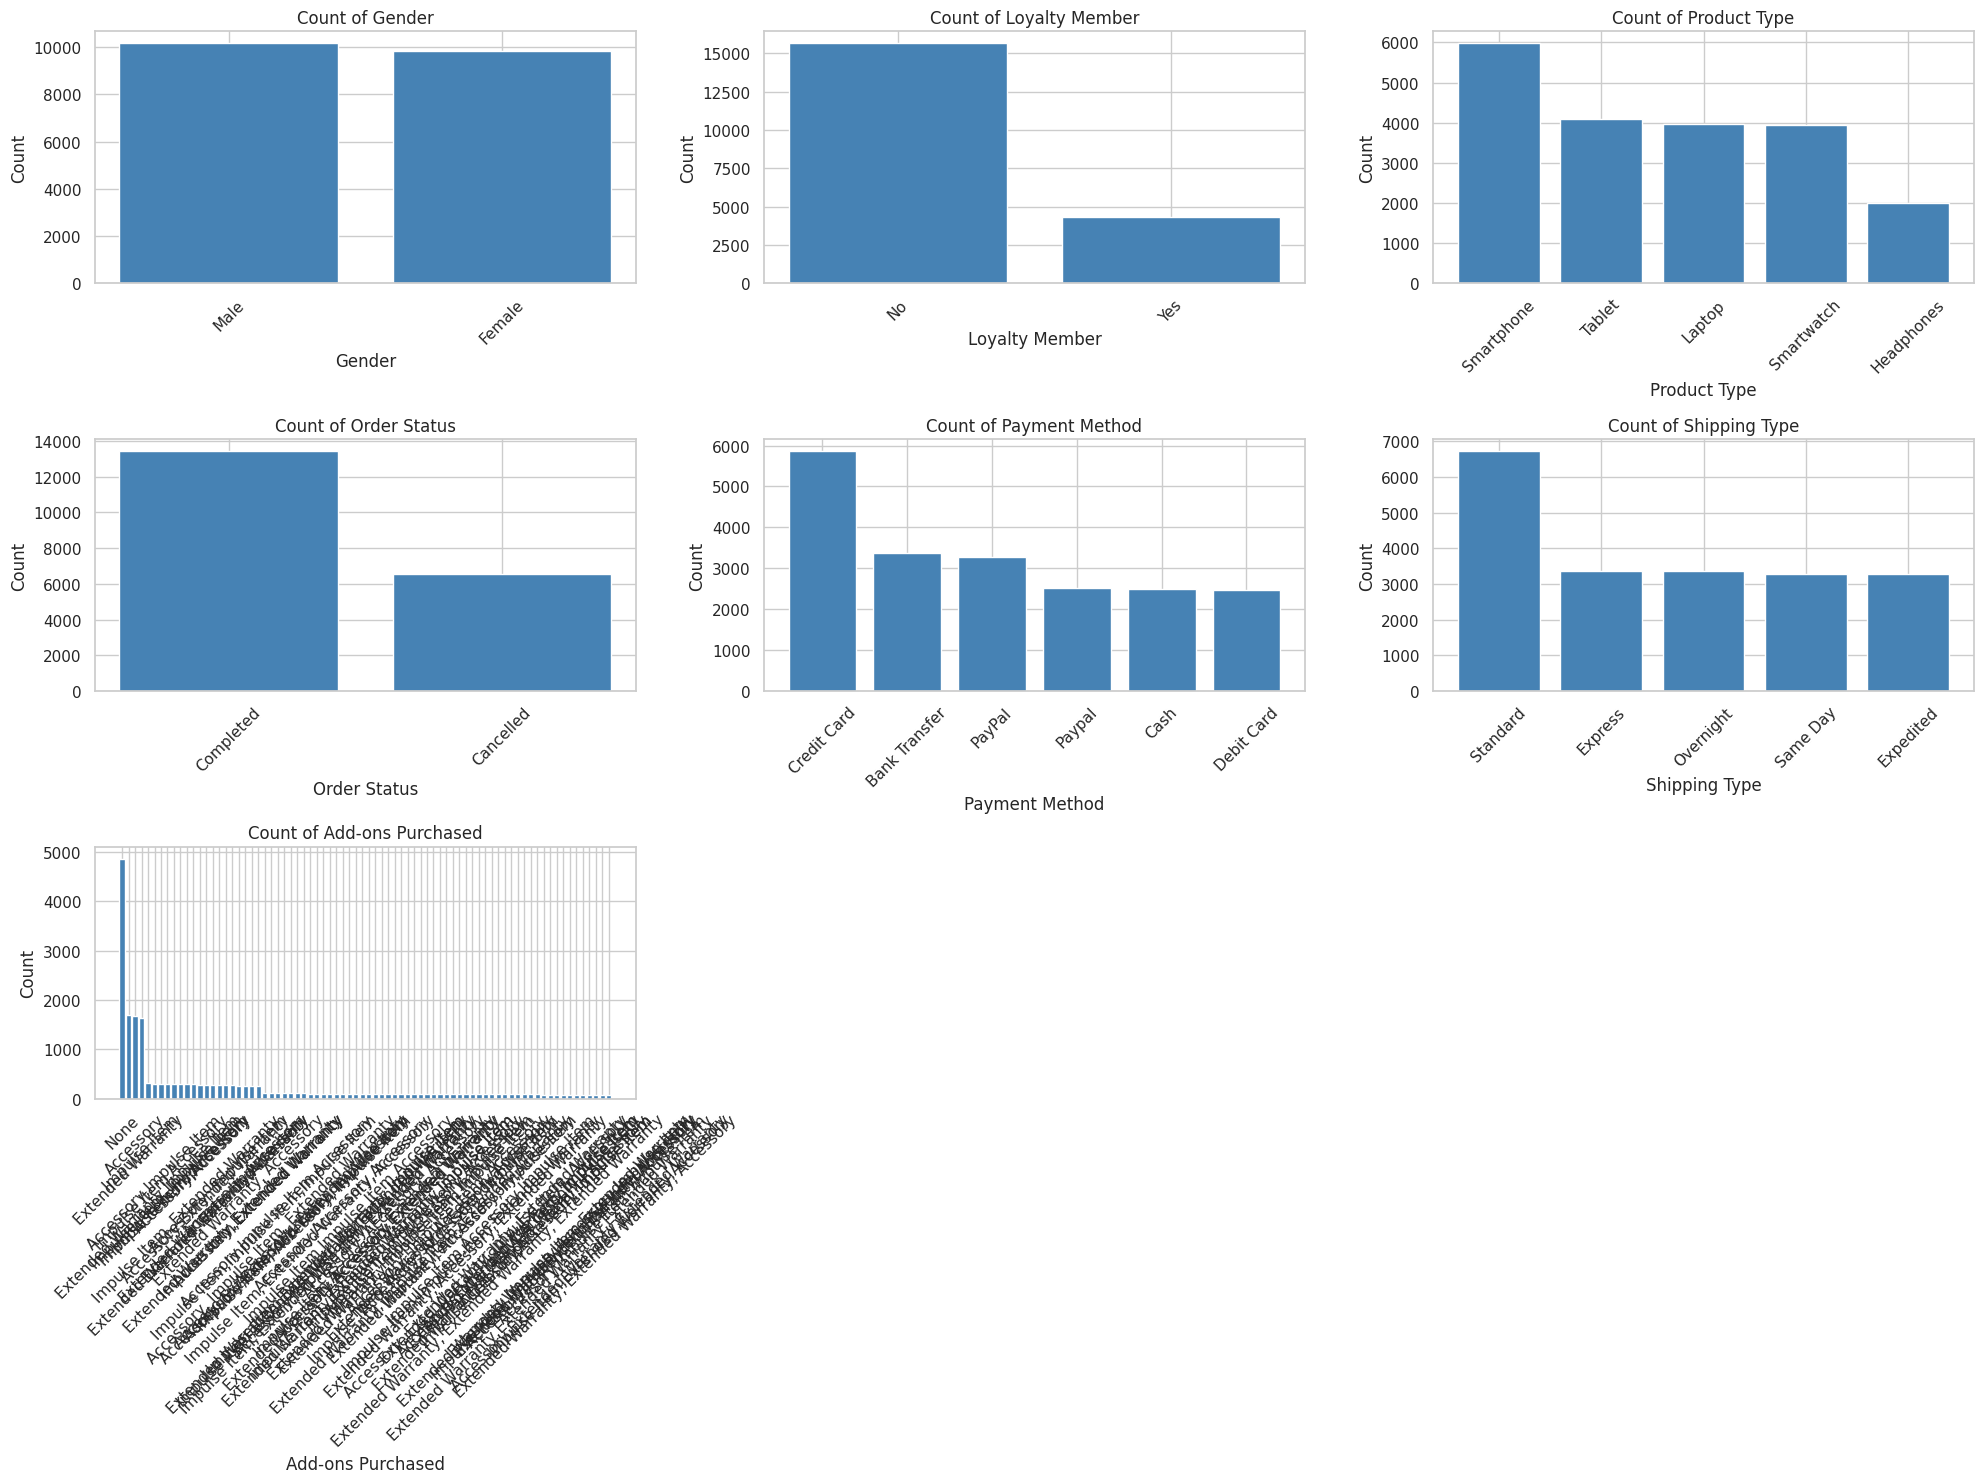

In [22]:
def check_univariate_categorical(df_eda, cols):
    n = len(cols)
    rows = -(-n // 3)

    plt.figure(figsize=(20, rows * 5))

    for index, col in enumerate(cols):
        plt.subplot(rows, 3, index + 1)

        counts = df_eda[col].value_counts()

        plt.bar(counts.index, counts.values, color='steelblue')

        plt.title(f'Count of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

check_univariate_categorical(df_eda, categorical_cols)


##### Distribution of Numerical Features

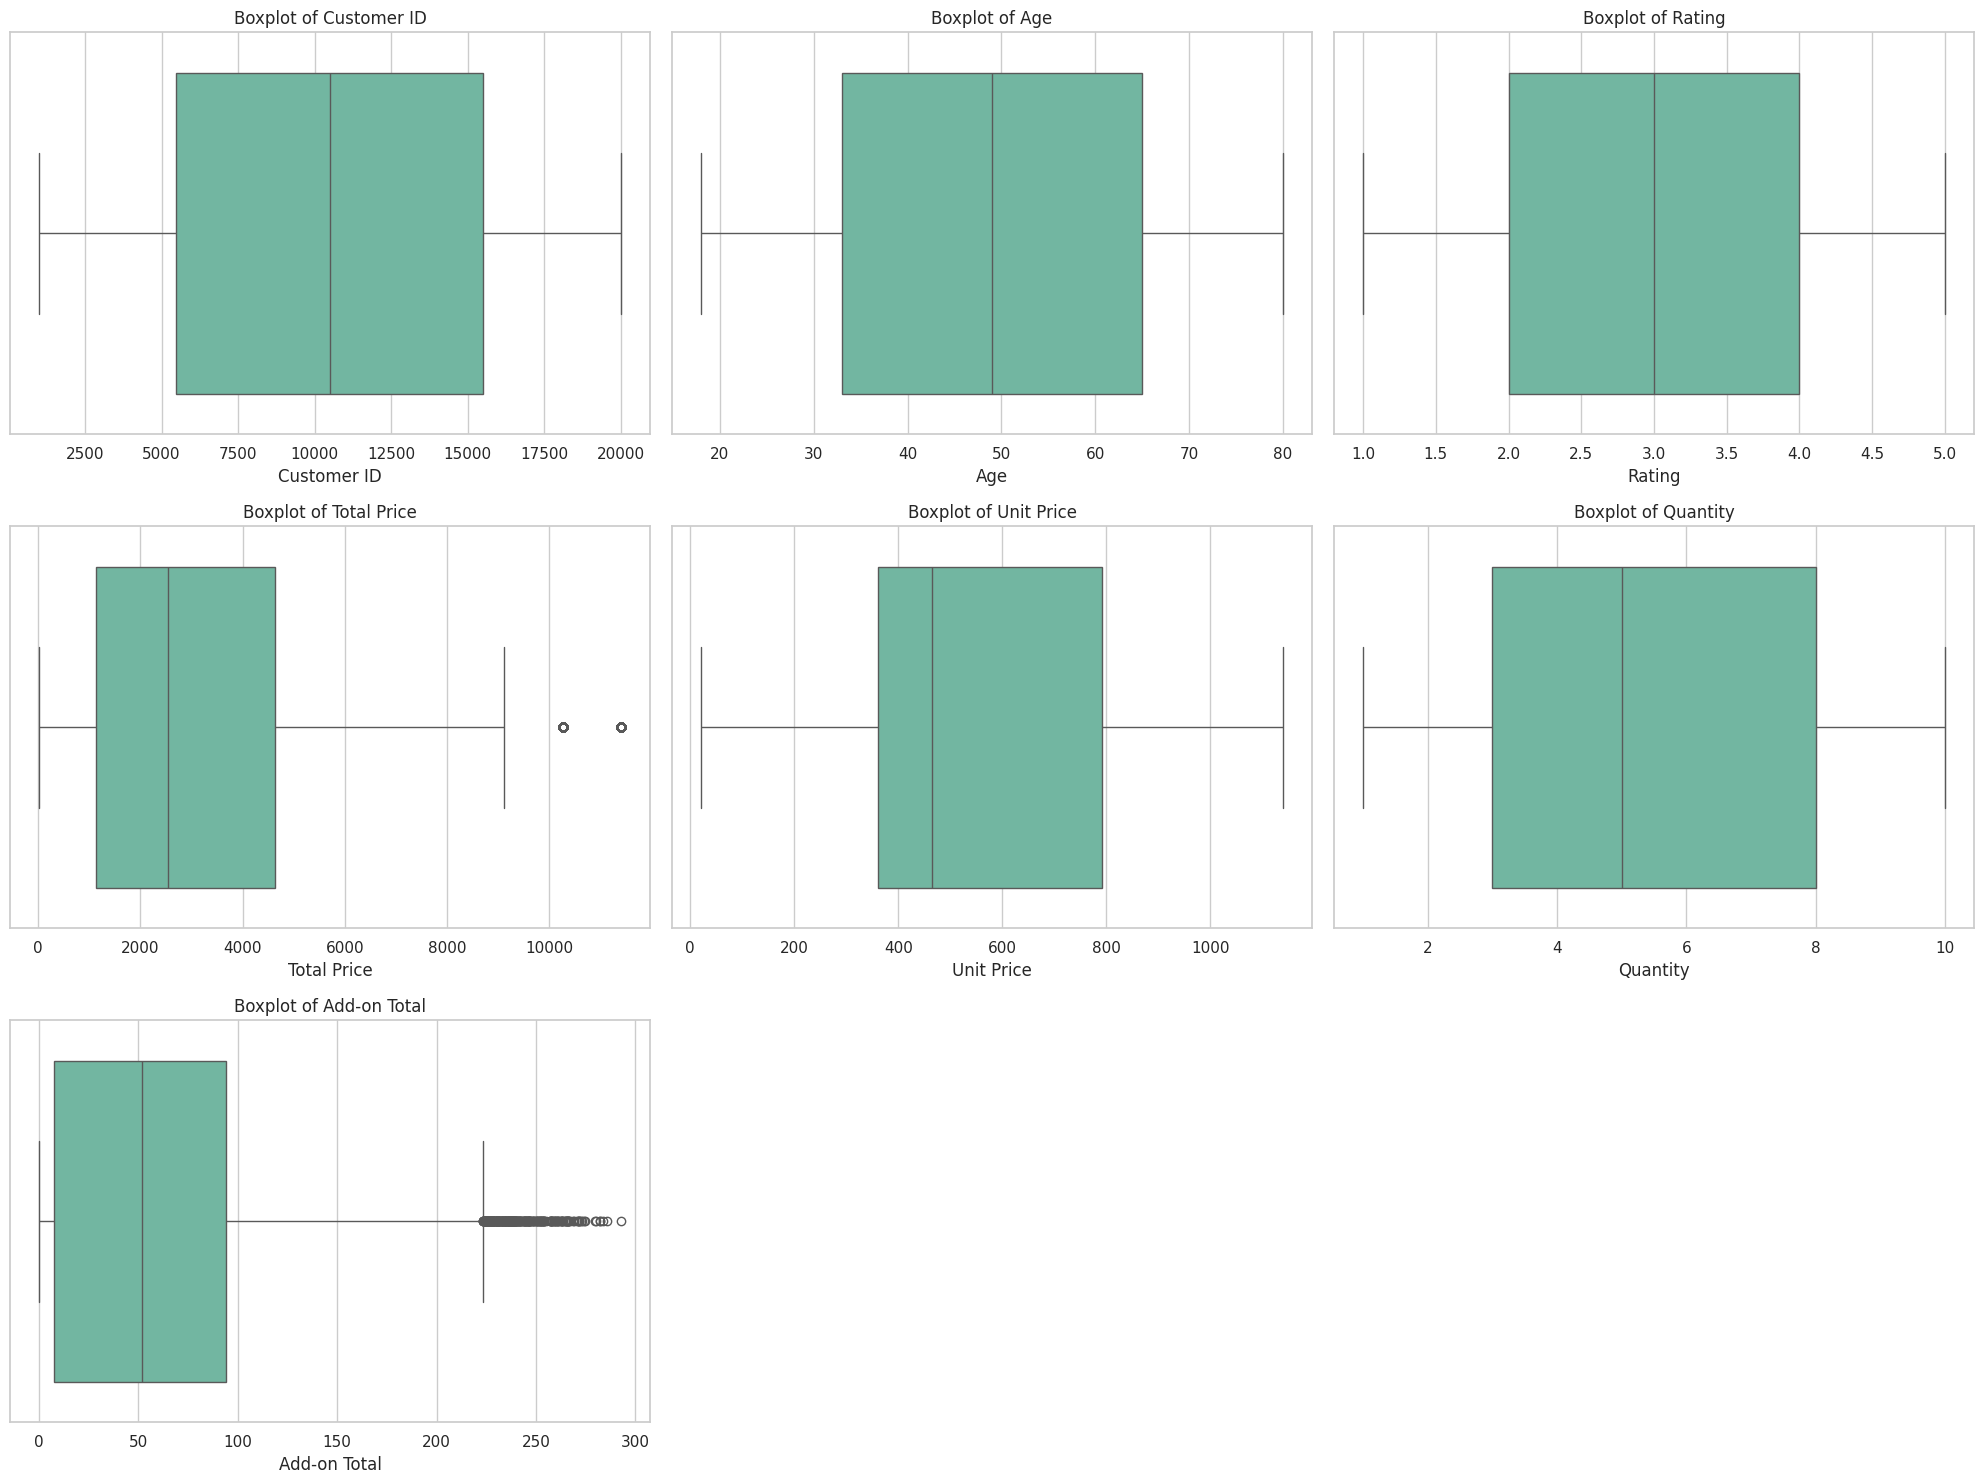

In [23]:
def check_univariate_numerical(df_eda, cols):
    n = len(cols)
    rows = -(-n // 3)

    plt.figure(figsize=(20, rows * 5))

    for index, col in enumerate(cols):
        plt.subplot(rows, 3, index + 1)
        sns.boxplot(x=df_eda[col])
        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()

check_univariate_numerical(df_eda, numerical_cols)

#### **Bivariate Analysis**

##### Classification Problem

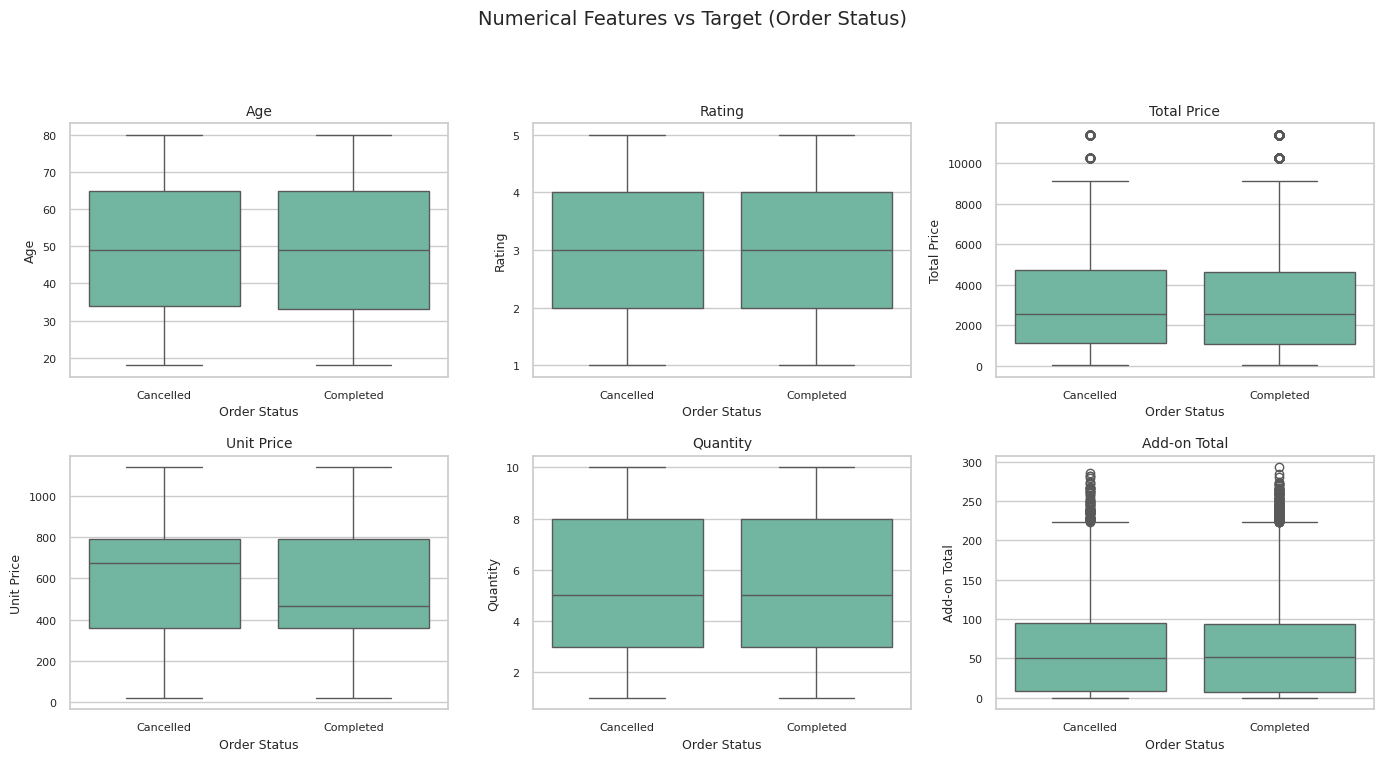

In [24]:
# Numerical
numerical_cols = ['Age', 'Rating', 'Total Price', 'Unit Price', 'Quantity', 'Add-on Total']

target = 'Order Status'

plt.figure(figsize=(14, 8))
plt.suptitle(f'Numerical Features vs Target ({target})', fontsize=14)

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df_eda, x=target, y=col)

    plt.title(f'{col}', fontsize=10)
    plt.xlabel(target, fontsize=9)
    plt.ylabel(col, fontsize=9)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

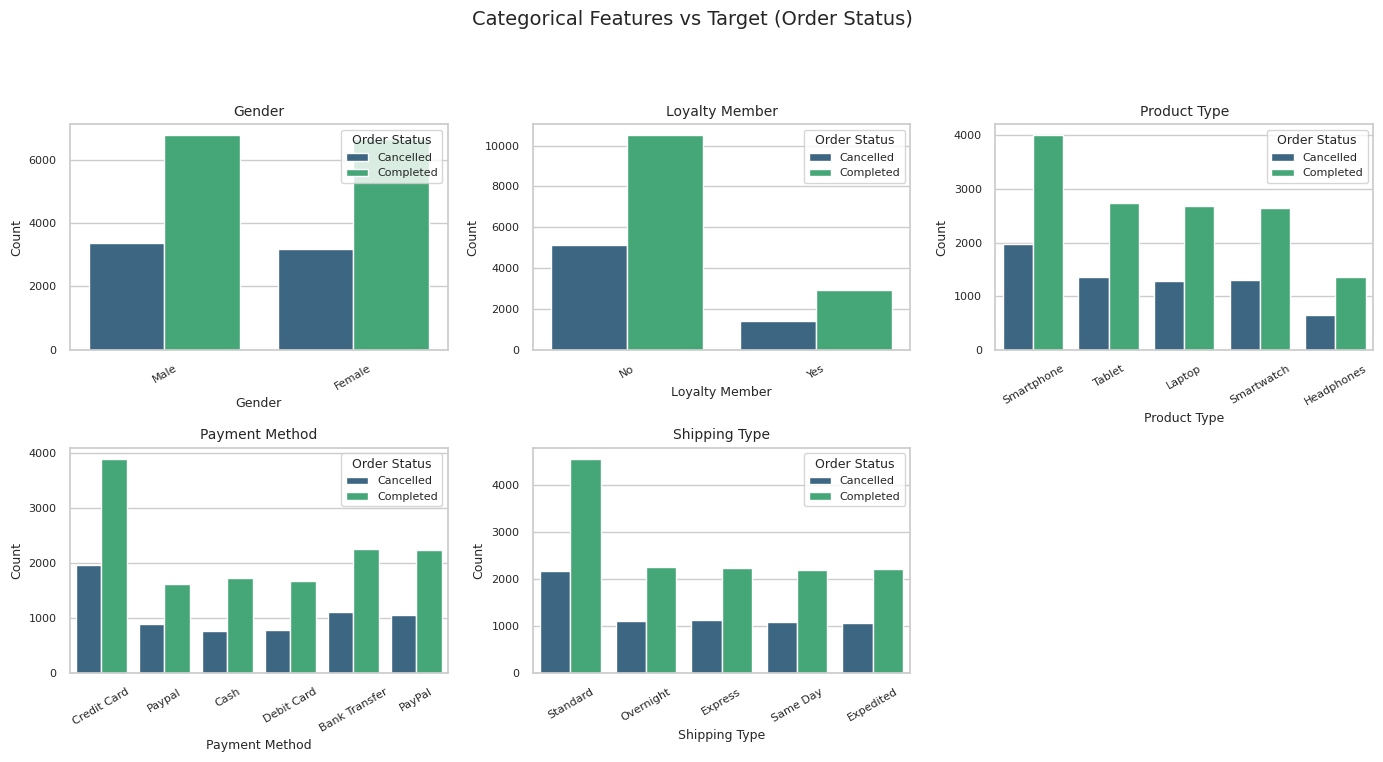

In [25]:
# Categorical
categorical_cols = ['Gender', 'Loyalty Member', 'Product Type',
                    'Payment Method', 'Shipping Type']

target = 'Order Status'

plt.figure(figsize=(14, 8))
plt.suptitle(f'Categorical Features vs Target ({target})', fontsize=14)

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df_eda, x=col, hue=target, palette='viridis')

    plt.title(f'{col}', fontsize=10)
    plt.xlabel(col, fontsize=9)
    plt.ylabel('Count', fontsize=9)
    plt.xticks(rotation=30, fontsize=8)
    plt.yticks(fontsize=8)
    plt.legend(title=target, fontsize=8, title_fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

##### Regression Problem

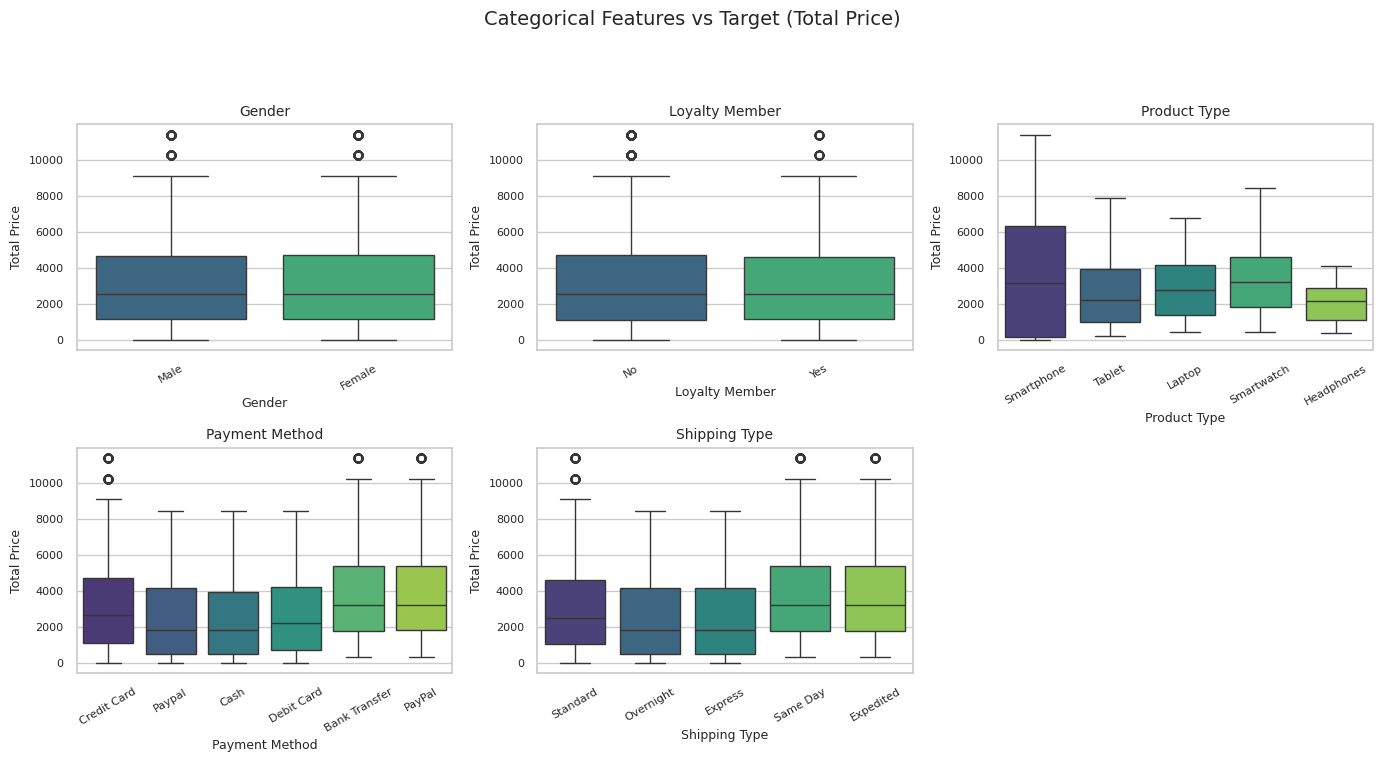

In [26]:
# Categorical
target = 'Total Price'

categorical_cols = [col for col in categorical_cols if col != 'Add-ons']

plt.figure(figsize=(14, 8))
plt.suptitle(f'Categorical Features vs Target ({target})', fontsize=14)

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')

    plt.title(f'{col}', fontsize=10)
    plt.xlabel(col, fontsize=9)
    plt.ylabel(target, fontsize=9)
    plt.xticks(rotation=30, fontsize=8)
    plt.yticks(fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

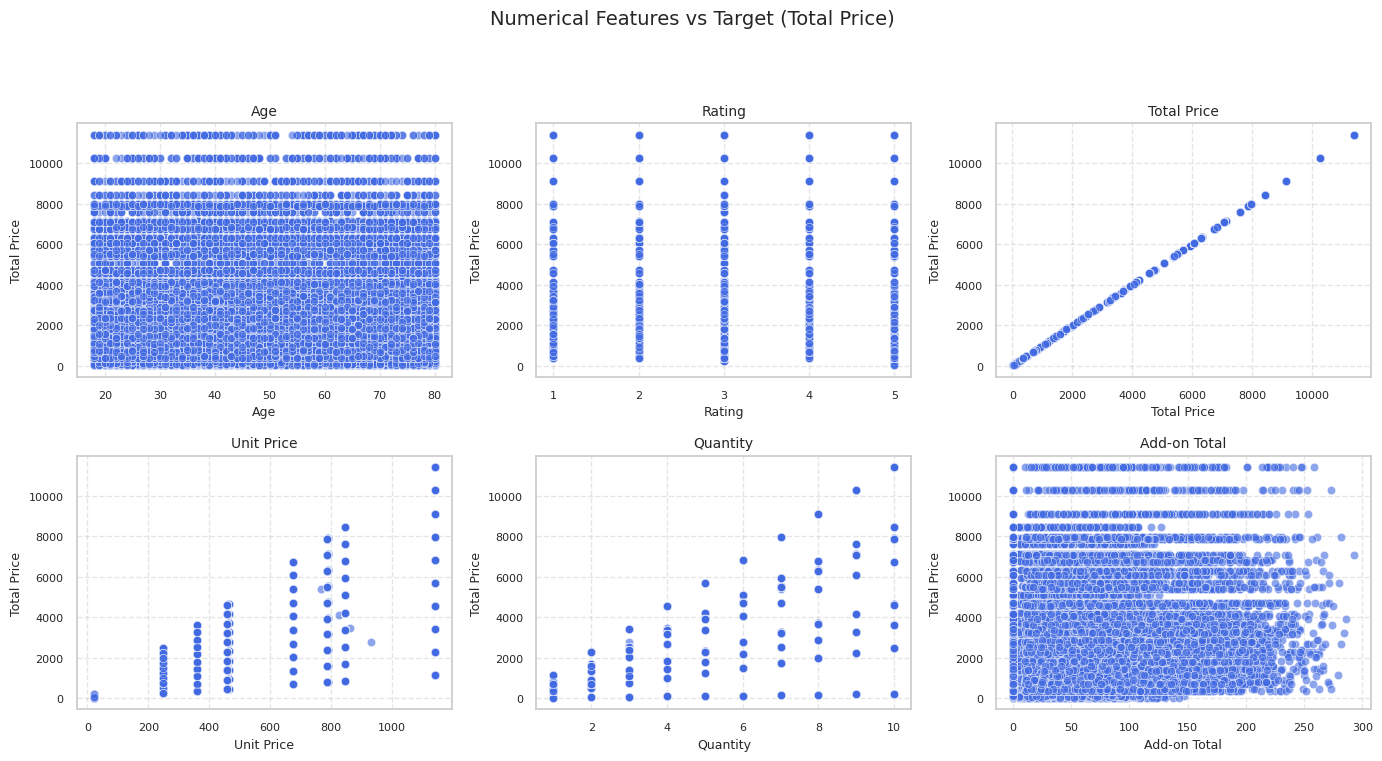

In [27]:
# Numerical
target = 'Total Price'

plt.figure(figsize=(14, 8))
plt.suptitle(f'Numerical Features vs Target ({target})', fontsize=14)

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(data=df_eda, x=col, y=target, color='royalblue', alpha=0.6)

    plt.title(f'{col}', fontsize=10)
    plt.xlabel(col, fontsize=9)
    plt.ylabel(target, fontsize=9)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

### **Statistical Analysis**

##### Classification Problem

In [28]:
# ANOVA Numerical Features
from scipy import stats
target = 'Order Status'
numerical_cols = ['Age', 'Rating', 'Total Price', 'Unit Price', 'Quantity', 'Add-on Total']

print("--- ANOVA Test: Numerical Features vs Order Status ---")
print(f"{'Feature':<15} {'F-Score':<10} {'P-Value':<10} {'Result'}")
print("-" * 55)

for col in numerical_cols:
    # Group samples by target
    group_completed = df_eda[df_eda[target] == 'Completed'][col]
    group_cancelled = df_eda[df_eda[target] == 'Cancelled'][col]

    # Perform One-Way ANOVA
    f_score, p_value = stats.f_oneway(group_completed, group_cancelled)

    # Interpret Result (p < 0.05 is significant)
    significance = "Significant" if p_value < 0.05 else "Not Significant"

    print(f"{col:<15} {f_score:<10.4f} {p_value:<10.4f} {significance}")

--- ANOVA Test: Numerical Features vs Order Status ---
Feature         F-Score    P-Value    Result
-------------------------------------------------------
Age             0.0534     0.8173     Not Significant
Rating          0.3497     0.5543     Not Significant
Total Price     0.2585     0.6112     Not Significant
Unit Price      0.2342     0.6284     Not Significant
Quantity        0.0280     0.8671     Not Significant
Add-on Total    0.0153     0.9014     Not Significant


In [29]:
from scipy.stats import chi2_contingency

# Chi-Square Test (Categorical Features)
categorical_cols = ['Gender', 'Loyalty Member', 'Product Type', 'Payment Method', 'Shipping Type']

print("--- Chi-Square Test: Categorical Features vs Order Status ---")
print(f"{'Feature':<15} {'Chi2':<10} {'P-Value':<10} {'Result'}")
print("-" * 55)

for col in categorical_cols:
    contingency_table = pd.crosstab(df_eda[col], df_eda[target])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Interpret Result (p < 0.05 is significant)
    significance = "Significant" if p < 0.05 else "Not Significant"

    print(f"{col:<15} {chi2:<10.4f} {p:<10.4f} {significance}")

--- Chi-Square Test: Categorical Features vs Order Status ---
Feature         Chi2       P-Value    Result
-------------------------------------------------------
Gender          1.8625     0.1723     Not Significant
Loyalty Member  0.0100     0.9203     Not Significant
Product Type    0.8745     0.9282     Not Significant
Payment Method  15.4538    0.0086     Significant
Shipping Type   3.4975     0.4783     Not Significant


##### Classification Problem

In [30]:
# Pearson Correlation (Numerical Features)
target = 'Total Price'
numerical_cols = ['Age', 'Rating', 'Unit Price', 'Quantity', 'Add-on Total']

print("--- Pearson Correlation: Numerical Features vs Total Price ---")
print(f"{'Feature':<15} {'Correlation':<12} {'P-Value':<10} {'Result'}")
print("-" * 55)

for col in numerical_cols:
    # Calculate Pearson Correlation (r) and p-value
    corr, p_value = stats.pearsonr(df_eda[col], df_eda[target])

    # Interpret Result (p < 0.05 is significant)
    significance = "Significant" if p_value < 0.05 else "Not Significant"

    print(f"{col:<15} {corr:<12.4f} {p_value:<10.4f} {significance}")

--- Pearson Correlation: Numerical Features vs Total Price ---
Feature         Correlation  P-Value    Result
-------------------------------------------------------
Age             0.0031       0.6615     Not Significant
Rating          -0.2324      0.0000     Significant
Unit Price      0.6740       0.0000     Significant
Quantity        0.6539       0.0000     Significant
Add-on Total    0.0839       0.0000     Significant


In [31]:
# ANOVA (Categorical Features)
categorical_cols = ['Gender', 'Loyalty Member', 'Product Type', 'Payment Method', 'Shipping Type']

print("--- ANOVA Test: Categorical Features vs Total Price ---")
print(f"{'Feature':<15} {'F-Score':<10} {'P-Value':<10} {'Result'}")
print("-" * 55)

for col in categorical_cols:
    # Group the target by category
    groups = [group[target].values for name, group in df_eda.groupby(col)]

    # Perform One-Way ANOVA
    f_score, p_value = stats.f_oneway(*groups)

    # Interpret Result (p < 0.05 is significant)
    significance = "Significant" if p_value < 0.05 else "Not Significant"

    print(f"{col:<15} {f_score:<10.4f} {p_value:<10.4f} {significance}")

--- ANOVA Test: Categorical Features vs Total Price ---
Feature         F-Score    P-Value    Result
-------------------------------------------------------
Gender          0.5760     0.4479     Not Significant
Loyalty Member  1.5610     0.2115     Not Significant
Product Type    194.9931   0.0000     Significant
Payment Method  159.7947   0.0000     Significant
Shipping Type   194.5130   0.0000     Significant


# **Sales & Revenue**

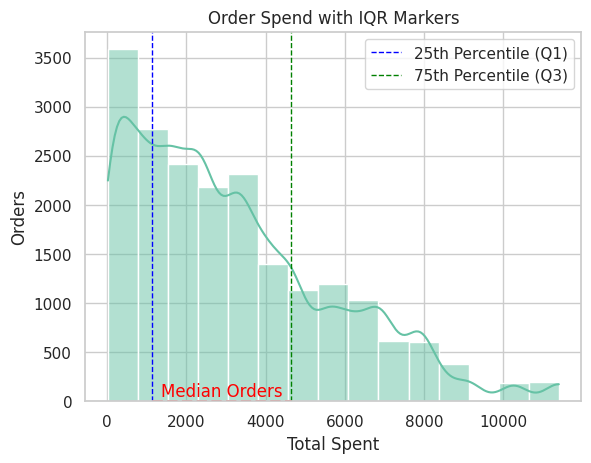

In [32]:
# Visualize price distribution

# Calculate IQR
Q1 = df_eda['Total Price'].quantile(0.25)
Q3 = df_eda['Total Price'].quantile(0.75)
IQR = Q3 - Q1
median = df_eda['Total Price'].median()

# Plot
sns.histplot(df_eda['Total Price'], bins=15, kde=True)

plt.axvline(Q1, color='blue', linestyle='dashed', linewidth=1,
            label='25th Percentile (Q1)')

plt.axvline(Q3, color='green', linestyle='dashed', linewidth=1,
            label='75th Percentile (Q3)')

plt.hlines(y=0, xmin=Q1, xmax=Q3,
           color='red', linestyle='dashed', linewidth=2)

plt.text((Q1 + Q3) / 2, 10, 'Median Orders',
         color='red', ha='center', va='bottom')

# title and labels
plt.title('Order Spend with IQR Markers')
plt.xlabel('Total Spent')
plt.ylabel('Orders', fontsize=12)

plt.legend()
plt.show()

### Product

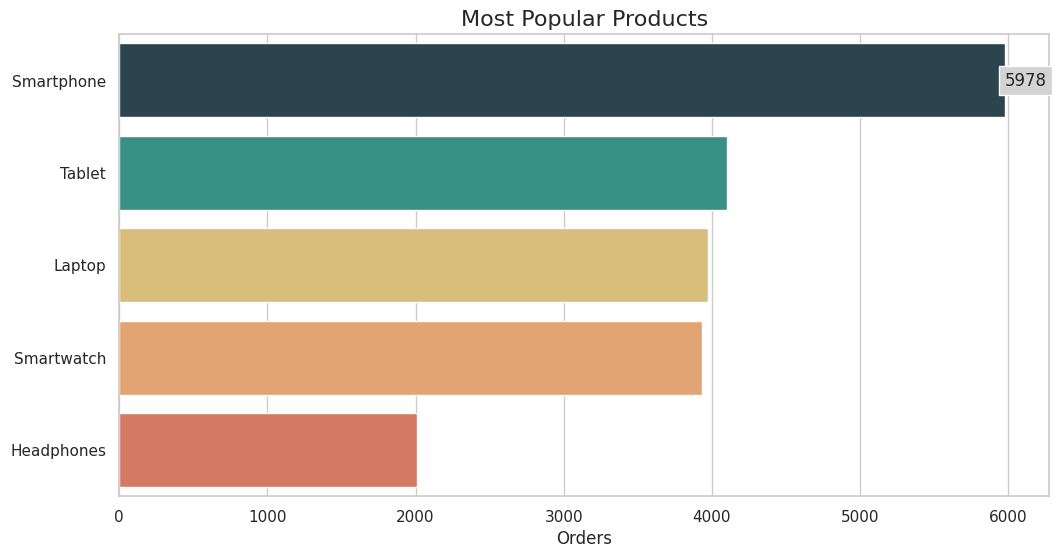

In [33]:
colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]


plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_eda, y='Product Type', order=df_eda['Product Type'].value_counts().index, palette=colors)
plt.title('Most Popular Products', fontsize=16)
plt.xlabel('Orders')
plt.ylabel('')

ax.bar_label(ax.containers[0], bbox=dict(facecolor='lightgrey'))
plt.show()

### Product sales by Month

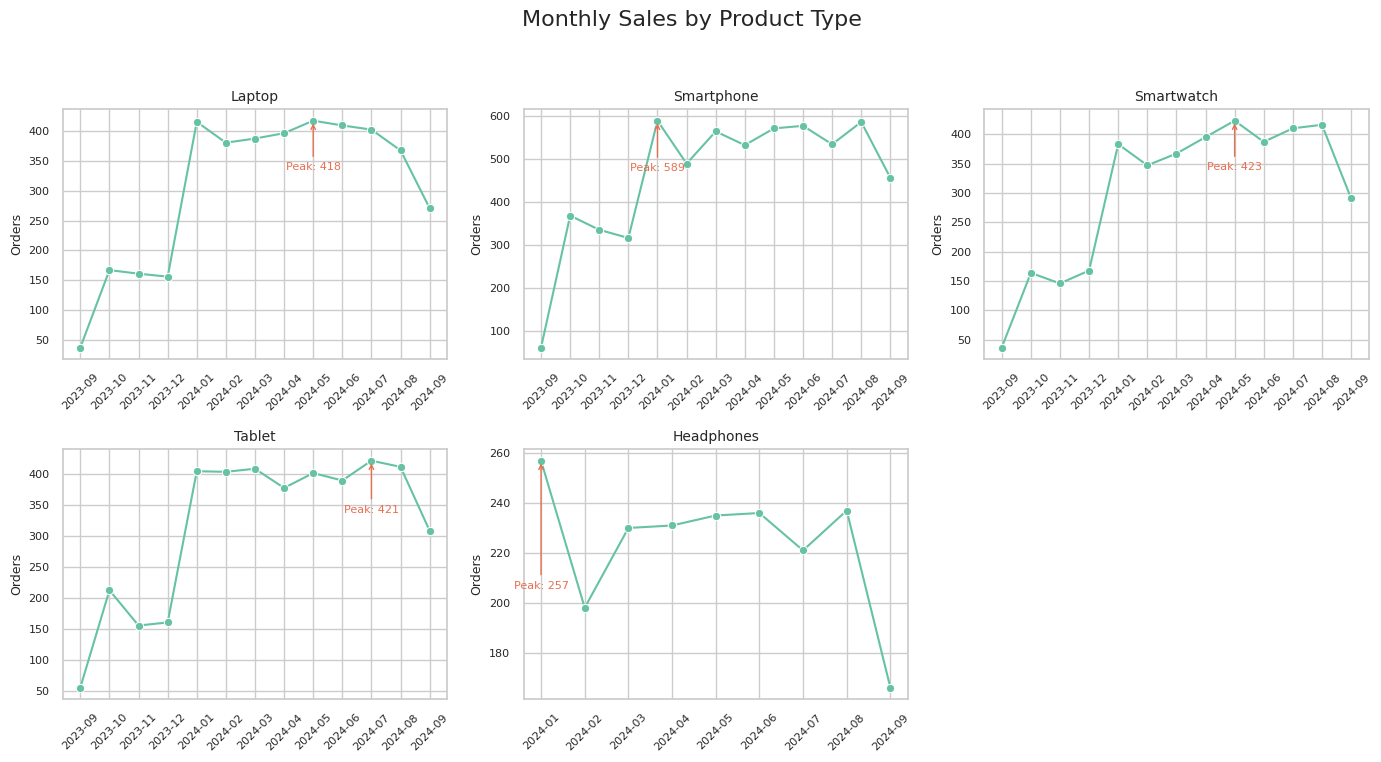

In [34]:
monthly_sales = df_eda.groupby(['YearMonth', 'Product Type']).size().reset_index(name='Sales')

# Convert 'YearMonth' to string since plotting doesnt like dates
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# Get unique product types
product_types = monthly_sales['Product Type'].unique()

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Monthly Sales by Product Type', fontsize=16)

axes = axes.flatten()

# Create a plot for each product
for i, product in enumerate(product_types):

    product_data = monthly_sales[monthly_sales['Product Type'] == product]

    sns.lineplot(
        data=product_data,
        x='YearMonth',
        y='Sales',
        marker='o',
        ax=axes[i]
    )

    # Mark the peak sales
    peak_sales = product_data['Sales'].max()
    peak_month = product_data[product_data['Sales'] == peak_sales]['YearMonth'].values[0]

    axes[i].annotate(
        f'Peak: {peak_sales}',
        xy=(peak_month, peak_sales),
        xytext=(peak_month, peak_sales * .8),
        arrowprops=dict(arrowstyle='->', color='#e76f51'),
        color='#e76f51',
        fontsize=8,
        ha='center'
    )

    axes[i].set_title(product, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Orders', fontsize=9)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

# Remove unused plots
if len(product_types) < len(axes):
    for i in range(len(product_types), len(axes)):
        fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [35]:
# Count the orders by order status
order_counts = df_eda.groupby('Order Status').size()

# Calculate cancelled percentage
cancelled_percentage = (order_counts.get('Cancelled', 0) / order_counts.sum()) * 100
cancelled_percentage = round(cancelled_percentage, 2)

print('Cancelled Percentage:', cancelled_percentage)

Cancelled Percentage: 32.84


### Shipping Type and Order Status

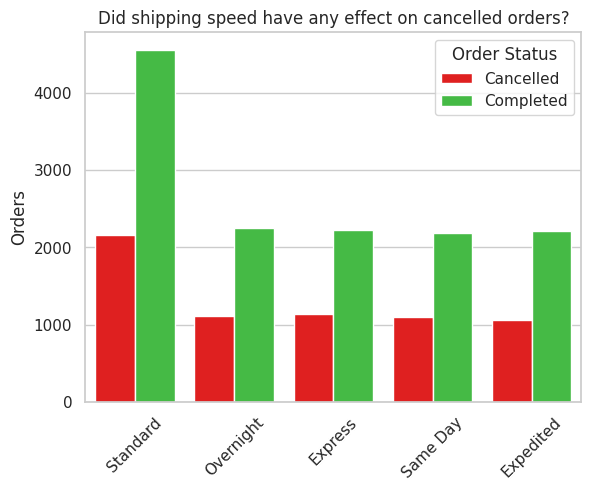

In [36]:
colors = ["#FF0000", "#32CD32"]

sns.countplot(data=df_eda, x='Shipping Type', hue='Order Status', palette=colors)

plt.title('Did shipping speed have any effect on cancelled orders?')
plt.xlabel('')
plt.ylabel('Orders')

plt.xticks(rotation=45)
plt.legend(title='Order Status')

plt.show()

In [37]:
# Count the orders by shipping type
shipping_counts = df_eda.groupby(['Shipping Type', 'Order Status']).size().unstack(fill_value=0)

# Calculate cancelled percentage
shipping_counts['Cancelled Percentage'] = (shipping_counts.get('Cancelled', 0) / shipping_counts.sum(axis=1)) * 100
shipping_counts['Cancelled Percentage'] = shipping_counts['Cancelled Percentage'].round(2)

shipping_counts

Order Status,Cancelled,Completed,Cancelled Percentage
Shipping Type,,,
Expedited,1062,2210,32.46
Express,1139,2227,33.84
Overnight,1110,2247,33.07
Same Day,1093,2187,33.32
Standard,2164,4561,32.18


## Add-Ons Handling

In [38]:
add_ons_df = df_eda.copy()

# Split the add ons into a separate column
add_ons_df['All Add-ons'] = add_ons_df['Add-ons Purchased'].str.split(',')
add_ons_df = add_ons_df.explode('All Add-ons')

# Remove white space around the add ons
add_ons_df['All Add-ons'] = add_ons_df['All Add-ons'].str.strip()

# Count the add ons
add_ons_df['All Add-ons'].value_counts().reset_index()

,All Add-ons,count
0,Impulse Item,10234
1,Accessory,10048
2,Extended Warranty,9975
3,None,4868


#### Show for Completed Orders

In [39]:
order_status_counts = add_ons_df.groupby(['Order Status', 'All Add-ons']).size().reset_index(name='Count')

order_status_counts_completed = order_status_counts[order_status_counts['Order Status'] == 'Completed']
order_status_counts_completed.columns = ['Status', 'Add-ons', 'Count']
order_status_counts_completed.sort_values(by='Count', ascending=False)

,Status,Add-ons,Count
6,Completed,Impulse Item,6888
4,Completed,Accessory,6713
5,Completed,Extended Warranty,6713
7,Completed,None,3287


#### Show for Cancelled Orders

In [40]:
order_status_counts_cancelled = order_status_counts[order_status_counts['Order Status'] == 'Cancelled']

order_status_counts_cancelled.sort_values(by='Count', ascending=False)

,Order Status,All Add-ons,Count
2,Cancelled,Impulse Item,3346
0,Cancelled,Accessory,3335
1,Cancelled,Extended Warranty,3262
3,Cancelled,None,1581


In [41]:
shipping_type_counts = add_ons_df.groupby(['Shipping Type', 'All Add-ons']).size().reset_index(name='Count')

shipping_type_counts.sort_values(by='Count', ascending=False)

,Shipping Type,All Add-ons,Count
18,Standard,Impulse Item,3473
16,Standard,Accessory,3403
17,Standard,Extended Warranty,3363
6,Express,Impulse Item,1717
10,Overnight,Impulse Item,1706
5,Express,Extended Warranty,1706
4,Express,Accessory,1694
8,Overnight,Accessory,1685
14,Same Day,Impulse Item,1677
2,Expedited,Impulse Item,1661


In [42]:
top_addons_by_ship = shipping_type_counts.loc[shipping_type_counts.groupby('Shipping Type')['Count'].idxmax()]

# Sort values in new data
top_addons_by_ship.sort_values(by='Count', ascending=False)

,Shipping Type,All Add-ons,Count
18,Standard,Impulse Item,3473
6,Express,Impulse Item,1717
10,Overnight,Impulse Item,1706
14,Same Day,Impulse Item,1677
2,Expedited,Impulse Item,1661


### Revenue for each shipping type

In [43]:
# will count both completed and Cancelled orders
revenue_by_shipping = df_eda.groupby('Shipping Type')['Total Price'].sum().reset_index()

# Setting new column names
revenue_by_shipping.columns = ['Shipping Type', 'Total Revenue']
revenue_by_shipping = revenue_by_shipping.sort_values(by='Total Revenue', ascending=False).reset_index(drop=True)
revenue_by_shipping['Total Revenue'] = revenue_by_shipping['Total Revenue'].apply(lambda x: f"${x:,.2f}")
revenue_by_shipping

,Shipping Type,Total Revenue
0,Standard,"$21,343,073.55"
1,Expedited,"$12,437,526.21"
2,Same Day,"$12,432,024.82"
3,Overnight,"$8,704,828.17"
4,Express,"$8,685,215.62"


In [44]:
avg_revenue_shipping = df_eda.groupby('Shipping Type')['Total Price'].mean().reset_index()

# column names
avg_revenue_shipping.columns = ['Shipping Type', 'Avg Revenue']
avg_revenue_shipping = avg_revenue_shipping.sort_values(by='Avg Revenue', ascending=False).reset_index(drop=True)
avg_revenue_shipping['Avg Revenue'] = avg_revenue_shipping['Avg Revenue'].apply(lambda x: f"${x:,.2f}")
avg_revenue_shipping

,Shipping Type,Avg Revenue
0,Expedited,"$3,801.20"
1,Same Day,"$3,790.25"
2,Standard,"$3,173.69"
3,Overnight,"$2,593.04"
4,Express,"$2,580.28"


In [45]:
tot_orders_by_ship = df_eda.groupby('Shipping Type').size().reset_index(name='Count')
total_count_shippings = tot_orders_by_ship['Count'].sum()

# Calculate percentages
tot_orders_by_ship['Percentage'] = ((tot_orders_by_ship['Count'] / total_count_shippings) * 100).round(2)
tot_orders_by_ship = tot_orders_by_ship.sort_values(by='Count', ascending=False)
tot_orders_by_ship

,Shipping Type,Count,Percentage
4,Standard,6725,33.62
1,Express,3366,16.83
2,Overnight,3357,16.78
3,Same Day,3280,16.40
0,Expedited,3272,16.36


### Do add-ons affect the total purchase price?

In [46]:
# make sure completed orders
completed_orders = df_eda[df_eda['Order Status'] == 'Completed'].copy()

# Calculate total purchase price without add-ons
completed_orders['Total Without Add-ons'] = completed_orders['Total Price'] - completed_orders['Add-on Total']

# Create a column indicating whether add-ons were purchased
completed_orders['Add-ons Purchased'] = completed_orders['Add-on Total'].apply(lambda x: 'Yes' if x > 0 else 'No')

completed_orders

,Customer ID,Age,Gender,Loyalty Member,Product Type,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,YearMonth,Total Without Add-ons
1,1000,53,Male,No,Tablet,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Yes,26.09,2024-04,715.00
2,1002,41,Male,No,Laptop,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,No,0.00,2023-10,1855.84
3,1002,41,Male,Yes,Smartphone,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,Yes,60.16,2024-08,3104.60
4,1003,75,Male,Yes,Smartphone,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Yes,35.56,2024-05,5.94
5,1004,41,Female,No,Smartphone,5,Completed,Credit Card,83.00,20.75,4,2024-05-26,Standard,Yes,65.78,2024-05,17.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,19995,69,Female,Yes,Laptop,3,Completed,Credit Card,5394.56,674.32,8,2024-08-09,Same Day,No,0.00,2024-08,5394.56
19994,19996,27,Female,No,Smartphone,5,Completed,Credit Card,3419.04,1139.68,3,2024-04-20,Same Day,No,0.00,2024-04,3419.04
19995,19996,27,Female,No,Smartphone,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,No,0.00,2024-06,6838.08
19997,19996,27,Female,No,Headphones,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,Yes,198.98,2024-08,1606.92


#####  Average order value with and without add ons

In [47]:
# Group by the presence of add-ons and calculate the average total price
add_on_aov = completed_orders.groupby('Add-ons Purchased')['Total Without Add-ons'].mean().round(2).reset_index()

# Rename the columns for clarity
add_on_aov.columns = ['Add-ons Purchased', 'AOV']
add_on_aov['AOV'] = add_on_aov['AOV'].apply(lambda x: f"${x:,.2f}")
add_on_aov

,Add-ons Purchased,AOV
0,No,"$3,198.85"
1,Yes,"$3,083.23"


##### Add-Ons by Loyalty Status

In [48]:
loyalty_df = df_eda.copy()

# Sort by Customer ID and Purchase Date
loyalty_df.sort_values(by=['Customer ID', 'Purchase Date'], inplace=True)

# Determine loyalty status
def determine_loyalty_status(group):
    statuses = []
    previous_status = None

    for _, row in group.iterrows():
        current_status = row['Loyalty Member']

        if previous_status is None:  # First order
            if current_status == 'Yes':
                statuses.append('Regular Member')
            else:
                statuses.append('Non Member')
        else:
            if previous_status == 'Yes' and current_status == 'No':
                statuses.append('Churned')
            elif previous_status == 'No' and current_status == 'Yes':
                statuses.append('New Member')
            elif current_status == 'Yes':
                statuses.append('Regular Member')
            else:
                statuses.append('Non Member')

        previous_status = current_status

    return pd.Series(statuses, index=group.index)

# Apply the function to get member statuses
loyalty_df['Loyalty Status'] = loyalty_df.groupby('Customer ID').apply(determine_loyalty_status).reset_index(drop=True)

# Display updated info
loyalty_df

,Customer ID,Age,Gender,Loyalty Member,Product Type,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,YearMonth,Loyalty Status
0,1000,53,Male,No,Smartphone,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21,2024-03,Non Member
1,1000,53,Male,No,Tablet,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09,2024-04,Non Member
2,1002,41,Male,No,Laptop,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,None,0.00,2023-10,Non Member
3,1002,41,Male,Yes,Smartphone,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16,2024-08,New Member
4,1003,75,Male,Yes,Smartphone,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56,2024-05,Regular Member
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,None,0.00,2024-06,Non Member
19996,19996,27,Female,Yes,Laptop,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,None,0.00,2024-07,New Member
19997,19996,27,Female,No,Headphones,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98,2024-08,Churned
19998,19997,27,Male,No,Headphones,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34,2024-01,Non Member


In [49]:
# dealing with completed orders
completed_orders = loyalty_df[loyalty_df['Order Status'] == 'Completed'].copy()

# Calculate total purchase price without add-ons
completed_orders['Total Without Add-ons'] = completed_orders['Total Price'] - completed_orders['Add-on Total']

# Create a column indicating whether add-ons were purchased
completed_orders['Add-ons Purchased'] = completed_orders['Add-on Total'].apply(lambda x: 'Yes' if x > 0 else 'No')

In [50]:
# Find AOV for orders WITHOUT add ons
without_addon_aov = completed_orders.groupby('Loyalty Status')['Total Without Add-ons'].mean().round(2).reset_index()
without_addon_aov.columns = ['Loyalty Status', 'AOV Without Add-ons']

# Get this same info for orders WITH add ons
with_addon_aov = completed_orders.groupby('Loyalty Status')['Total Price'].mean().round(2).reset_index()
with_addon_aov.columns = ['Loyalty Status', 'AOV With Add-ons']
combined_aov = pd.merge(with_addon_aov, without_addon_aov, on='Loyalty Status')
combined_aov = combined_aov.sort_values(by='AOV Without Add-ons', ascending=False)

# Format values to look like currency
combined_aov['AOV With Add-ons'] = combined_aov['AOV With Add-ons'].apply(lambda x: f"${x:,.2f}")
combined_aov['AOV Without Add-ons'] = combined_aov['AOV Without Add-ons'].apply(lambda x: f"${x:,.2f}")
combined_aov

,Loyalty Status,AOV With Add-ons,AOV Without Add-ons
0,Churned,"$3,283.80","$3,223.51"
1,New Member,"$3,248.03","$3,186.68"
2,Non Member,"$3,181.04","$3,118.82"
3,Regular Member,"$3,056.97","$2,993.61"


##### Most Popular Item for Loyalty Member

In [51]:
# Create copy from EDA dataframe
add_ons_df = df_eda.copy()

# Split the add ons into a separate column
add_ons_df['All Add-ons'] = add_ons_df['Add-ons Purchased'].str.split(',')
add_ons_df = add_ons_df.explode('All Add-ons')

# Remove white space around the add ons
add_ons_df['All Add-ons'] = add_ons_df['All Add-ons'].str.strip()


# Lets look what add on items are most popular for loyalty members
loyalty_addons = add_ons_df.groupby(['Loyalty Member', 'All Add-ons']).size().reset_index(name='Count')

# Find only the loyalty member info
member_addons = loyalty_addons[loyalty_addons['Loyalty Member'] == 'Yes']

total_count = member_addons['Count'].sum()

# Calculate percentages
member_addons['Percentage'] = ((member_addons['Count'] / total_count) * 100).round(2)

# Sort values by count or percentage
member_addons.sort_values(by='Count', ascending=False, inplace=True)
member_addons

,Loyalty Member,All Add-ons,Count,Percentage
4,Yes,Accessory,2251,29.56
6,Yes,Impulse Item,2168,28.47
5,Yes,Extended Warranty,2144,28.15
7,Yes,None,1053,13.83


##### Most Popular Item for Non-Loyalty Member

In [52]:
# Find only the loyalty member info
non_member_addons = loyalty_addons[loyalty_addons['Loyalty Member'] == 'No']

total_count_non = non_member_addons['Count'].sum()

# Calculate percentages
non_member_addons['Percentage'] = ((non_member_addons['Count'] / total_count_non) * 100).round(2)

# Sort values by count or percentage
non_member_addons.sort_values(by='Count', ascending=False, inplace=True)
non_member_addons

,Loyalty Member,All Add-ons,Count,Percentage
2,No,Impulse Item,8066,29.32
1,No,Extended Warranty,7831,28.47
0,No,Accessory,7797,28.34
3,No,None,3815,13.87


##### Add-Ons with Age

In [53]:
# Define age groups
bins = [18, 25, 35, 45, 55, 65, 75, 85]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']

# Create a new column for age buckets
add_ons_df['Age Group'] = pd.cut(add_ons_df['Age'], bins=bins, labels=labels, right=False)

# Group by age groups and All Add-ons
age_addons = add_ons_df.groupby(['Age Group', 'All Add-ons']).size().reset_index(name='Count')

age_addons

,Age Group,All Add-ons,Count
0,18-24,Accessory,1061
1,18-24,Extended Warranty,1074
2,18-24,Impulse Item,1124
3,18-24,None,534
4,25-34,Accessory,1611
5,25-34,Extended Warranty,1551
6,25-34,Impulse Item,1584
7,25-34,None,763
8,35-44,Accessory,1683
9,35-44,Extended Warranty,1664


In [54]:
# Top 5 Add Ons
age_addons.sort_values(by='Count', ascending=False).head()

,Age Group,All Add-ons,Count
10,35-44,Impulse Item,1720
8,35-44,Accessory,1683
9,35-44,Extended Warranty,1664
16,55-64,Accessory,1643
22,65-74,Impulse Item,1639


In [55]:
# Top add-on purchased by each age group
top_age_addons = age_addons.loc[age_addons.groupby('Age Group')['Count'].idxmax()]
top_age_addons.reset_index(drop=True)

,Age Group,All Add-ons,Count
0,18-24,Impulse Item,1124
1,25-34,Accessory,1611
2,35-44,Impulse Item,1720
3,45-54,Impulse Item,1633
4,55-64,Accessory,1643
5,65-74,Impulse Item,1639
6,75+,Impulse Item,919


# **Loyalty Membership**

In [56]:
# accurately count the Members by Customer ID
Member_counts = df_eda.groupby('Loyalty Member')['Customer ID'].nunique().reset_index()
Member_counts.columns = ['Loyalty Member', 'Count']
Member_counts = Member_counts.sort_values(by='Count', ascending=False)
Member_counts

,Loyalty Member,Count
0,No,10572
1,Yes,3834


In [57]:
New_Member_counts = loyalty_df.groupby('Loyalty Status')['Customer ID'].nunique().reset_index()
New_Member_counts.columns = ['Loyalty Status', 'Count']
New_Member_counts = New_Member_counts.sort_values(by='Count', ascending=False)
New_Member_counts

,Loyalty Status,Count
2,Non Member,9805
3,Regular Member,2682
0,Churned,1353
1,New Member,1328


### Loyalty Member History

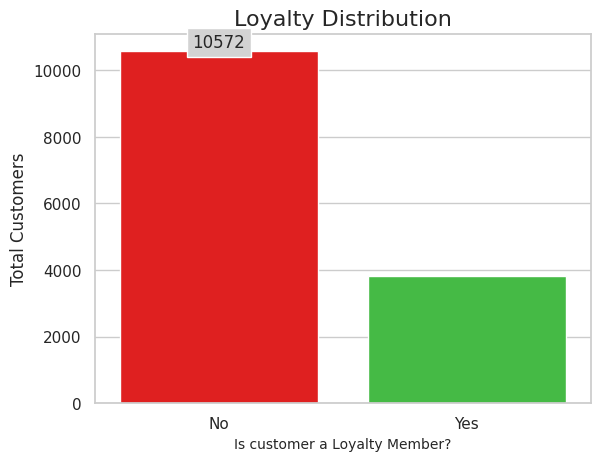

In [58]:
colors = ["#FF0000", "#32CD32"]

ax = sns.barplot(data=Member_counts, x='Loyalty Member', y='Count', palette=colors)
plt.title('Loyalty Distribution', fontsize=16)
plt.xlabel('Is customer a Loyalty Member?', fontsize=10)
plt.ylabel('Total Customers', fontsize=12)

ax.bar_label(ax.containers[0], bbox=dict(facecolor='lightgrey'))
plt.show()

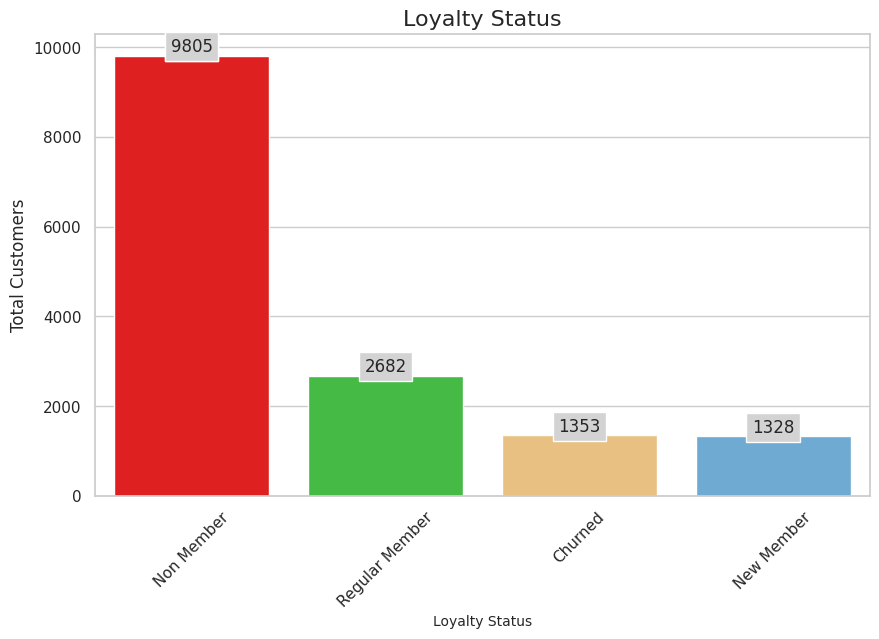

In [59]:
colors = ["#FF0000", "#32CD32", "#f8c471", "#5dade2"]

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=New_Member_counts, x='Loyalty Status', y='Count', palette=colors)
plt.title('Loyalty Status', fontsize=16)
plt.xlabel('Loyalty Status', fontsize=10)
plt.ylabel('Total Customers', fontsize=12)
ax.bar_label(ax.containers[0], bbox=dict(facecolor='lightgrey'))

for container in ax.containers:
    ax.bar_label(container, bbox=dict(facecolor='lightgrey'))
plt.xticks(rotation=45)
plt.show()

### Membership Over Time

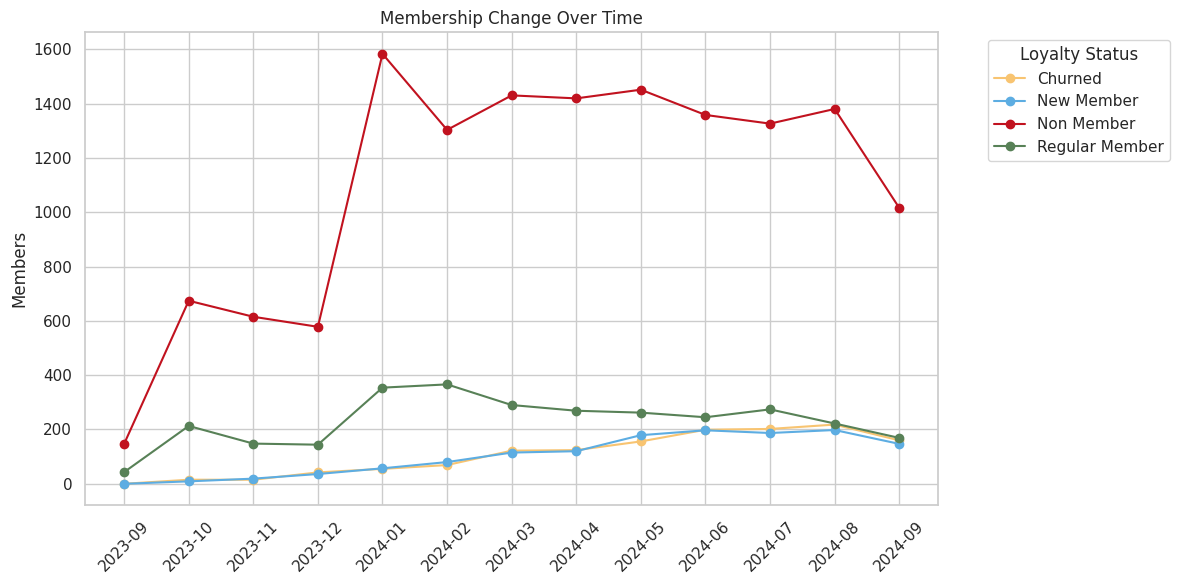

In [60]:
colors = {
    'Regular Member': "#588157",
    'Non Member': "#c1121f",
    'Churned': "#f8c471",
    'New Member': "#5dade2"
}

# Extract month and year from purchase date
loyalty_df['YearMonth'] = loyalty_df['Purchase Date'].dt.to_period('M')

# Count each loyalty status per month
members_counts = loyalty_df.groupby(['YearMonth', 'Loyalty Status']).size().reset_index(name='Count')

# Pivot the data to have statuses as columns
members_pivot = members_counts.pivot(index='YearMonth', columns='Loyalty Status', values='Count').fillna(0)

# Plot
plt.figure(figsize=(12, 6))

# Use a line plot for better visibility of trends
for status in members_pivot.columns:
    plt.plot(members_pivot.index.astype(str), members_pivot[status], marker='o', label=status, color=colors.get(status))

plt.title('Membership Change Over Time')
plt.xlabel('') # remove Date label
plt.ylabel('Members')
plt.xticks(rotation=45)
plt.legend(title='Loyalty Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Sales Over Time

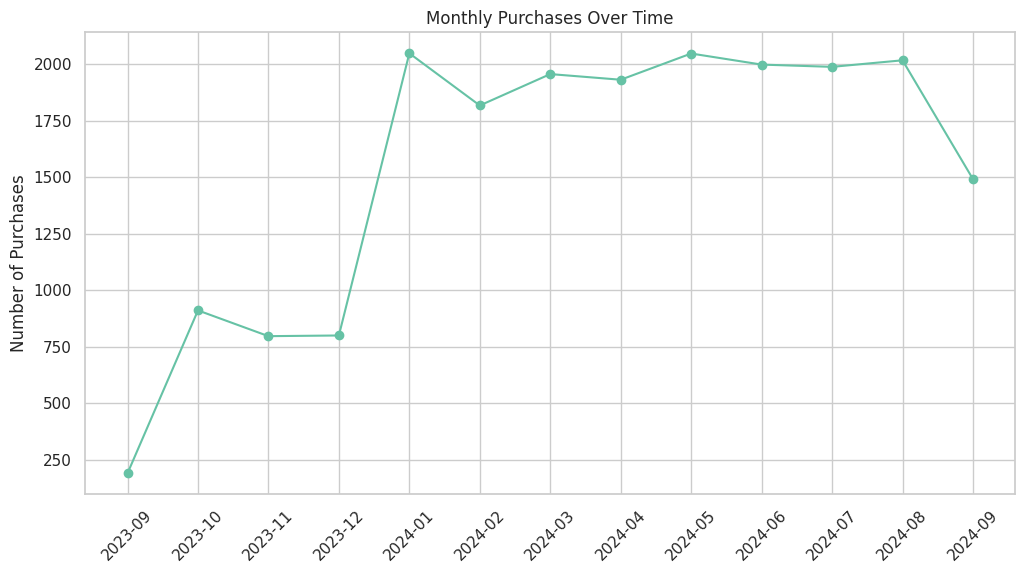

In [61]:
month_data = df_eda.set_index('Purchase Date')

# Resample months
monthly_counts = month_data['Customer ID'].resample('M').count()

# change date format to YearMonth
monthly_counts.index = monthly_counts.index.strftime('%Y-%m')


plt.figure(figsize=(12, 6))
monthly_counts.plot(marker='o', linestyle='-')
plt.title('Monthly Purchases Over Time')
plt.xlabel('')
plt.xticks(ticks=range(len(monthly_counts)), labels=monthly_counts.index, rotation=45)
plt.ylabel('Number of Purchases')
plt.show()


In [62]:
# Average quantity purchased per transaction
avg_quantity_products = df_eda.groupby('Product Type')['Quantity'].mean().reset_index(name='Avg Quantity')
avg_quantity_products.sort_values(by='Avg Quantity', ascending=False)

,Product Type,Avg Quantity
0,Headphones,5.560915
4,Tablet,5.519737
3,Smartwatch,5.498475
2,Smartphone,5.463366
1,Laptop,5.432671


### Average Order Value between Loyalty Members and Non-members

In [63]:
avg_orders_members = loyalty_df.groupby('Loyalty Status')['Total Price'].mean().round(2).reset_index()
avg_orders_members.columns = ['Loyalty Status', 'AOV']
avg_orders_members['AOV'] = avg_orders_members['AOV'].apply(lambda x: f"${x:,.2f}")
avg_orders_members.sort_values(by='AOV', ascending=False)

,Loyalty Status,AOV
1,New Member,"$3,237.40"
2,Non Member,"$3,192.94"
0,Churned,"$3,182.00"
3,Regular Member,"$3,092.65"


# **Total Revenue from Completed Sales**

In [64]:
total_revenue = completed_orders['Total Price'].sum()
formatted_revenue = "${:,.2f}".format(total_revenue)

print('Total Revenue: ', formatted_revenue)

Total Revenue:  $42,629,615.57


In [65]:
totals_df = df_eda.copy()
totals_df['Purchase Month'] = pd.to_datetime(totals_df['Purchase Date'])
totals_df.set_index('Purchase Month', inplace=True)

monthly_revenue = totals_df[totals_df['Order Status'] == 'Completed'].resample('M')['Total Price'].sum()
monthly_revenue = monthly_revenue.reset_index()
monthly_revenue['Purchase Month'] = monthly_revenue['Purchase Month'].dt.strftime('%Y-%m')

formatted_revenue = monthly_revenue.copy()
formatted_revenue = formatted_revenue.sort_values(by='Total Price', ascending=False).head().reset_index(drop=True) # Reset index just for looks
formatted_revenue['Total Price'] = formatted_revenue['Total Price'].apply(lambda x: f"${x:,.2f}")

formatted_revenue.head()

,Purchase Month,Total Price
0,2024-01,"$4,516,277.81"
1,2024-06,"$4,465,994.71"
2,2024-05,"$4,462,915.20"
3,2024-07,"$4,460,946.48"
4,2024-08,"$4,378,433.10"


## Top 5 Month

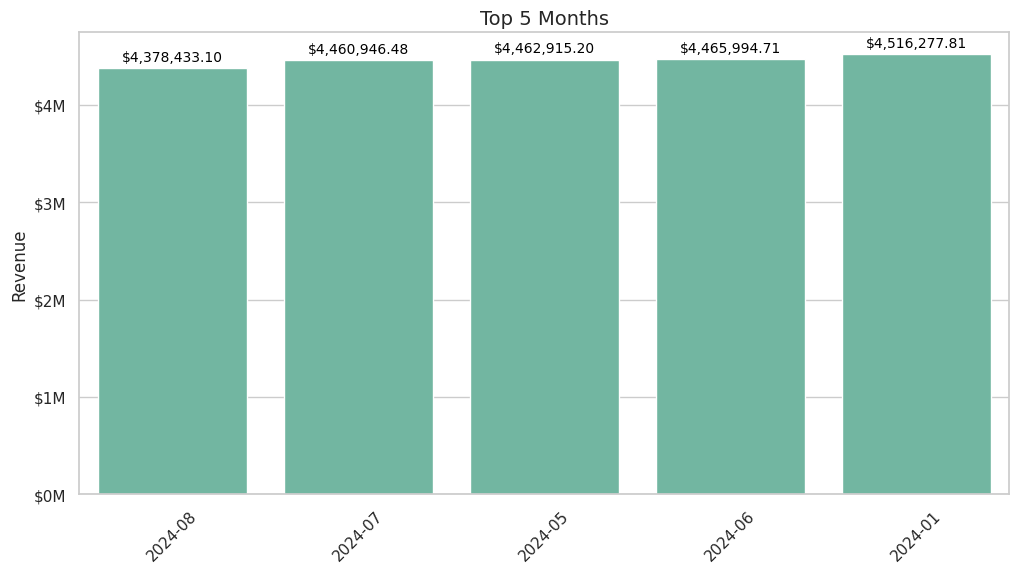

In [66]:
# Get only the top 5 months
top5_months = monthly_revenue.sort_values(by='Total Price').tail(5)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top5_months, x='Purchase Month', y='Total Price')
plt.title('Top 5 Months', fontsize=14)
plt.xlabel('')
plt.ylabel('Revenue')
plt.xticks(rotation=45)


# Show the revenue above each bar
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10,
                color='black',
                xytext=(0, 3),  # adjust value to move text
                textcoords='offset points')

# Format y-axis ticks
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1_000_000:.0f}M'))


plt.show()


## Revenue by Month

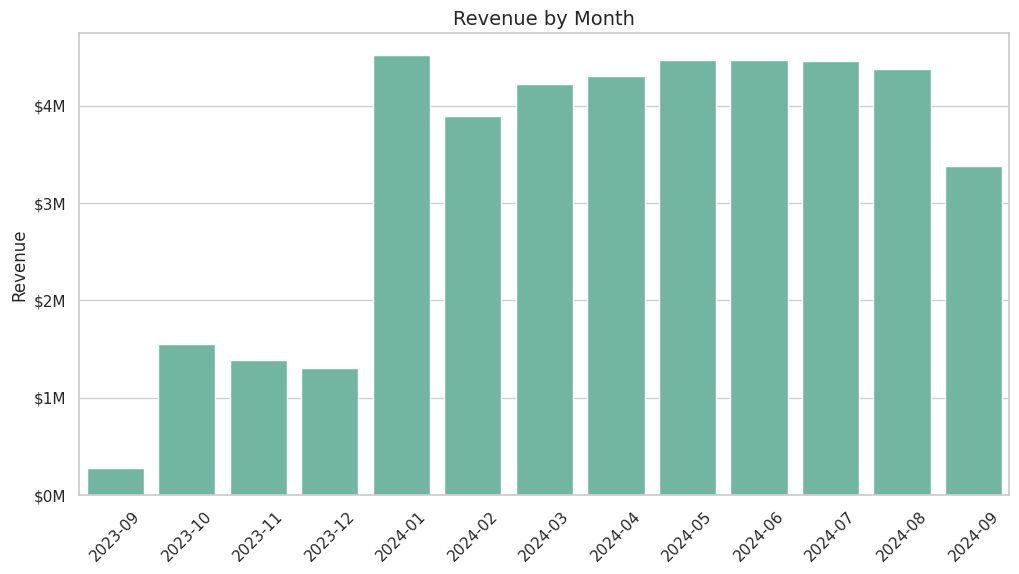

In [67]:
top_months = monthly_revenue

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_months, x='Purchase Month', y='Total Price')
plt.title('Revenue by Month', fontsize=14)
plt.xlabel('')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

# Format y-axis ticks
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1_000_000:.0f}M'))

plt.show()

## Revenue by Season

In [68]:
# map months to seasons
def get_season(month):
    month = int(month.split('-')[1])  # Convert month to number
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Apply the function to get our seasons
top_months['Season'] = top_months['Purchase Month'].apply(get_season)

# Group by season and sum the total price
seasonal = top_months.groupby('Season')['Total Price'].sum().reset_index()

seasonal.columns = ['Season', 'Total Revenue']

seasonal = seasonal.sort_values(by='Total Revenue', ascending=False).reset_index(drop=True)

seasonal['Total Revenue'] = seasonal['Total Revenue'].apply(lambda x: f"${x:,.2f}")

seasonal

,Season,Total Revenue
0,Summer,"$13,305,374.29"
1,Spring,"$12,989,365.54"
2,Winter,"$9,723,550.84"
3,Fall,"$6,611,324.90"


# **Revenue by Product**

In [69]:
# Total Revenue for each product

product_sales = df.copy()

# Filter by completed orders and then group the data
product_sales = product_sales[product_sales['Order Status'] == 'Completed'].groupby('Product Type')['Total Price'].sum().reset_index()

# Rename columns for clarity
product_sales.columns = ['Product Type', 'Total Revenue']

product_sales = product_sales.sort_values(by='Total Revenue', ascending=False).reset_index(drop=True)

product_sales['Total Revenue'] = product_sales['Total Revenue'].apply(lambda x: f"${x:,.2f}")

product_sales

,Product Type,Total Revenue
0,Smartphone,"$14,407,835.84"
1,Smartwatch,"$9,398,591.23"
2,Laptop,"$8,365,905.25"
3,Tablet,"$7,722,632.25"
4,Headphones,"$2,734,651.00"


## Top 5 Month

In [70]:
# Product Sales by month

monthly_products = df.copy()

# Filter for completed orders
monthly_products = monthly_products[monthly_products['Order Status'] == 'Completed']

monthly_products['Purchase Month'] = monthly_products['Purchase Date'].dt.to_period('M')

# sum total price by month and product type
monthly_products = monthly_products.groupby(['Purchase Month', 'Product Type'])['Total Price'].sum().reset_index()

# Sort results
monthly_products = monthly_products.sort_values(by=['Total Price', 'Product Type'], ascending=[False, True])

# Find TOP month for each product
top_monthly_products = monthly_products.loc[monthly_products.groupby('Product Type')['Total Price'].idxmax()]

# rename columns for clarity
top_monthly_products.columns = ['Top Month', 'Product', 'Total Revenue']

# Sort
top_monthly_products = top_monthly_products.sort_values(by='Total Revenue', ascending=False).reset_index(drop=True) # Reset index just for looks

# Format values to currency
top_monthly_products['Total Revenue'] = top_monthly_products['Total Revenue'].apply(lambda x: f"${x:,.2f}")


top_monthly_products

,Top Month,Product,Total Revenue
0,2024-06,Smartphone,"$1,626,691.74"
1,2024-05,Smartwatch,"$1,010,548.13"
2,2024-07,Tablet,"$978,979.74"
3,2024-01,Laptop,"$942,944.64"
4,2024-01,Headphones,"$365,875.34"


In [71]:
# Convert 'Purchase Month' back to datetime for plotting
monthly_products['Purchase Month'] = monthly_products['Purchase Month'].dt.to_timestamp()

## Product Perform Overtime

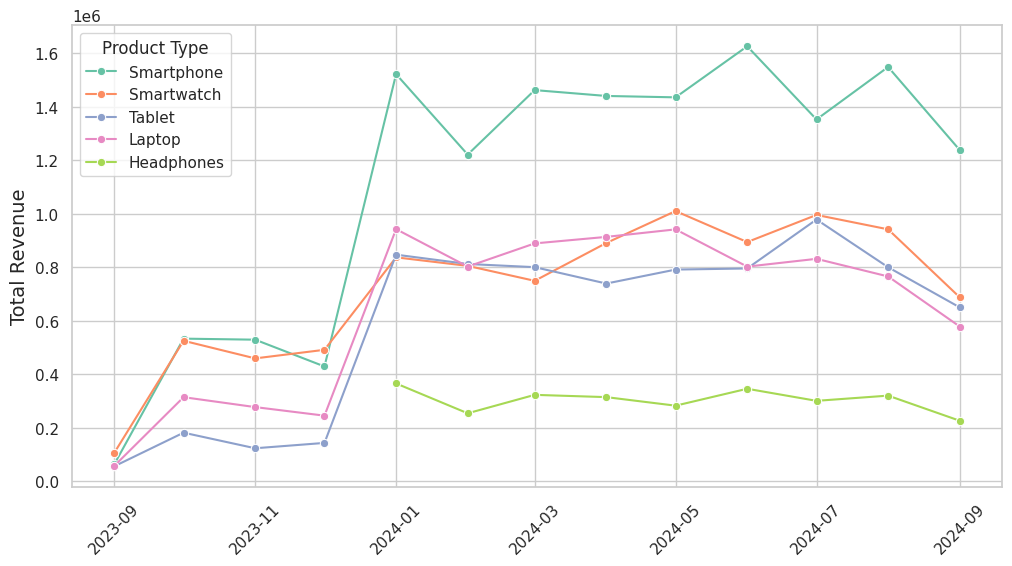

In [72]:
# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_products, x='Purchase Month', y='Total Price', hue='Product Type', marker='o')
# plt.title('How does each product perform over time?', fontsize=16)
plt.xlabel('') # remove pointless labels
plt.ylabel('Total Revenue', fontsize=14)
plt.xticks(rotation=45)

plt.show()

## Average Customer Age for Each Product

In [73]:
df_eda['Age'].describe()

,Age
count,20000.000000
mean,48.994100
std,18.038745
min,18.000000
25%,33.000000
50%,49.000000
75%,65.000000
max,80.000000


In [74]:
# Overall average age?
average_age_overall = df_eda['Age'].mean().round(2)
print('Average Age: ', average_age_overall)

Average Age:  48.99


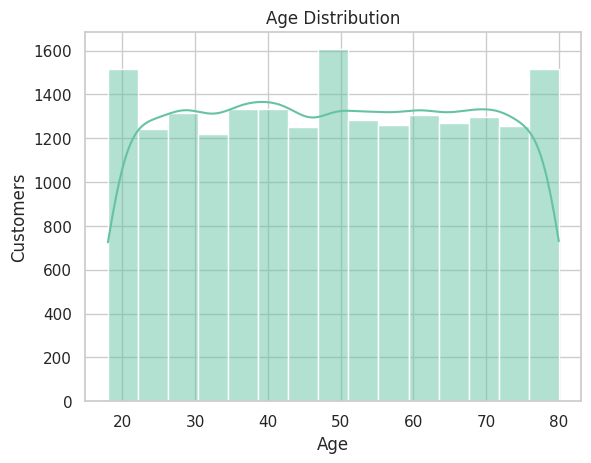

In [75]:
# Visualize age distibution

# Plot
sns.histplot(df_eda['Age'], bins=15, kde=True)
plt.title('Age Distribution')
plt.ylabel('Customers', fontsize=12)
plt.show()

In [76]:
# Avg age customer for each product
average_age = df_eda.groupby('Product Type')['Age'].mean().round(2).reset_index()
average_age

,Product Type,Age
0,Headphones,48.24
1,Laptop,48.76
2,Smartphone,49.10
3,Smartwatch,49.31
4,Tablet,49.14


In [77]:
# look at youngest and oldest
age_extremes = df_eda.groupby('Product Type')['Age'].agg(['min', 'max']).reset_index()
age_extremes

,Product Type,min,max
0,Headphones,18,80
1,Laptop,18,80
2,Smartphone,18,80
3,Smartwatch,18,80
4,Tablet,18,80


# **Gender Distribution**

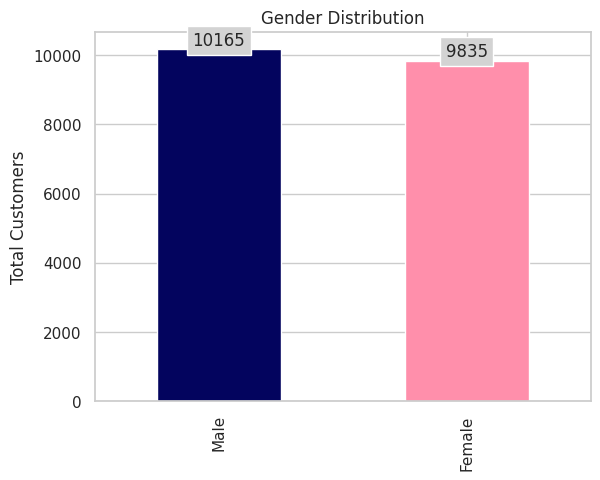

In [78]:
# Visualization
gender_counts = df_eda['Gender'].value_counts()
colors = ["#03045e", "#ff8fab"]

# Plot
ax = gender_counts.plot(kind='bar', color=colors)
plt.title('Gender Distribution')
plt.xlabel('')
plt.ylabel('Total Customers')

# Add value labels to the bars
ax.bar_label(ax.containers[0], bbox=dict(facecolor='lightgrey'))
plt.show()

In [79]:
purch_by_gender = df_eda.groupby('Product Type')['Gender'].value_counts().reset_index(name='Count')
purch_by_gender = purch_by_gender.sort_values(by='Count', ascending=False)
purch_by_gender

,Product Type,Gender,Count
4,Smartphone,Male,2998
5,Smartphone,Female,2980
8,Tablet,Male,2088
6,Smartwatch,Male,2033
9,Tablet,Female,2016
2,Laptop,Male,2002
3,Laptop,Female,1971
7,Smartwatch,Female,1901
0,Headphones,Male,1044
1,Headphones,Female,967


In [80]:
purch_by_gender.sort_values(by='Count', ascending=False).head(5)

,Product Type,Gender,Count
4,Smartphone,Male,2998
5,Smartphone,Female,2980
8,Tablet,Male,2088
6,Smartwatch,Male,2033
9,Tablet,Female,2016


# **Rating Distribution**

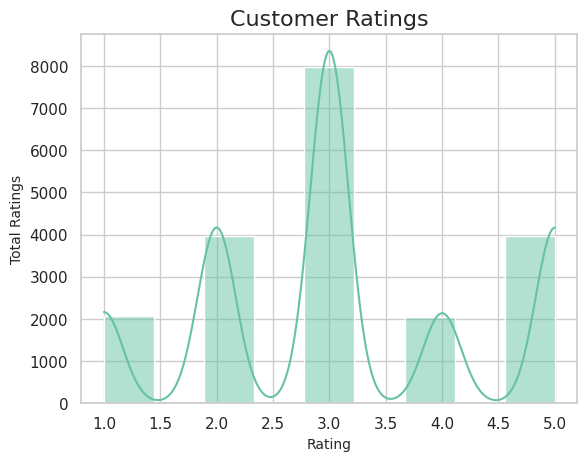

In [81]:
sns.histplot(df_eda['Rating'], bins=9, kde=True)
plt.title('Customer Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=10)
plt.ylabel('Total Ratings', fontsize=10)
plt.show()

In [82]:
loyalty_df.groupby('Loyalty Status')['Rating'].mean().reset_index()

,Loyalty Status,Rating
0,Churned,3.089325
1,New Member,3.067708
2,Non Member,3.091036
3,Regular Member,3.121707


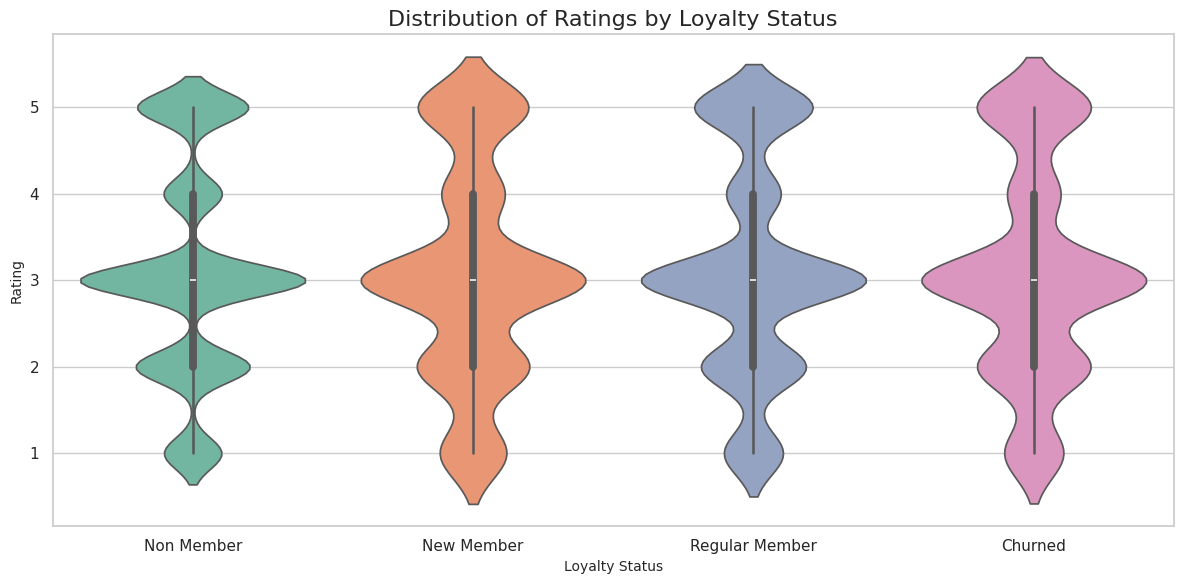

In [83]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=loyalty_df,
    x='Loyalty Status',
    y='Rating',
    palette='Set2'
)

plt.title('Distribution of Ratings by Loyalty Status', fontsize=16)
plt.xlabel('Loyalty Status', fontsize=10)
plt.ylabel('Rating', fontsize=10)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [84]:
# calculate average rating
sentiment_analysis = df_eda.groupby('Order Status')['Rating'].mean().reset_index()

sentiment_analysis.columns = ['Order Status', 'Average Rating']

print(sentiment_analysis)

  Order Status  Average Rating
0    Cancelled        3.086632
1    Completed        3.097528


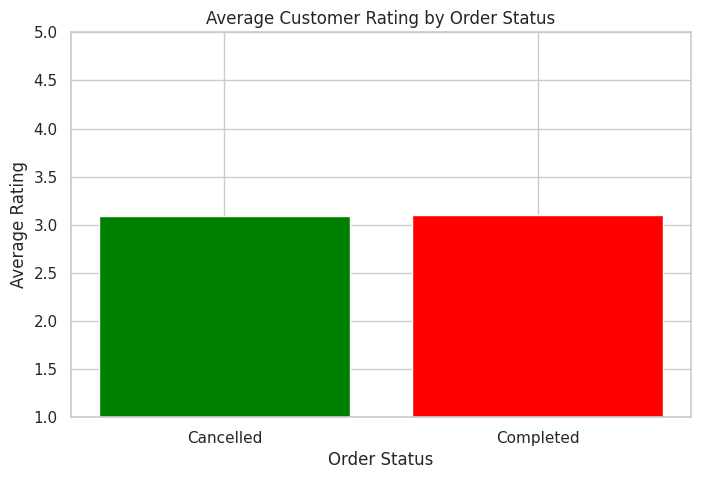

In [85]:
# Visualize the rating analysis
plt.figure(figsize=(8, 5))
plt.bar(sentiment_analysis['Order Status'], sentiment_analysis['Average Rating'], color=['green', 'red'])
plt.title('Average Customer Rating by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Average Rating')
plt.ylim(1, 5) # Set vertical scale between 1-5

plt.show()

# **Payment Analysis**

In [86]:
# fix all 'PayPal' values
df_eda['Payment Method'] = df_eda['Payment Method'].replace({'PayPal': 'Paypal'})

# Make sure all values were fixed
df_eda[df_eda['Payment Method'] == 'PayPal']

,Customer ID,Age,Gender,Loyalty Member,Product Type,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,YearMonth


In [87]:
df_eda['Payment Method'].value_counts().reset_index()

,Payment Method,count
0,Credit Card,5868
1,Paypal,5798
2,Bank Transfer,3371
3,Cash,2492
4,Debit Card,2471


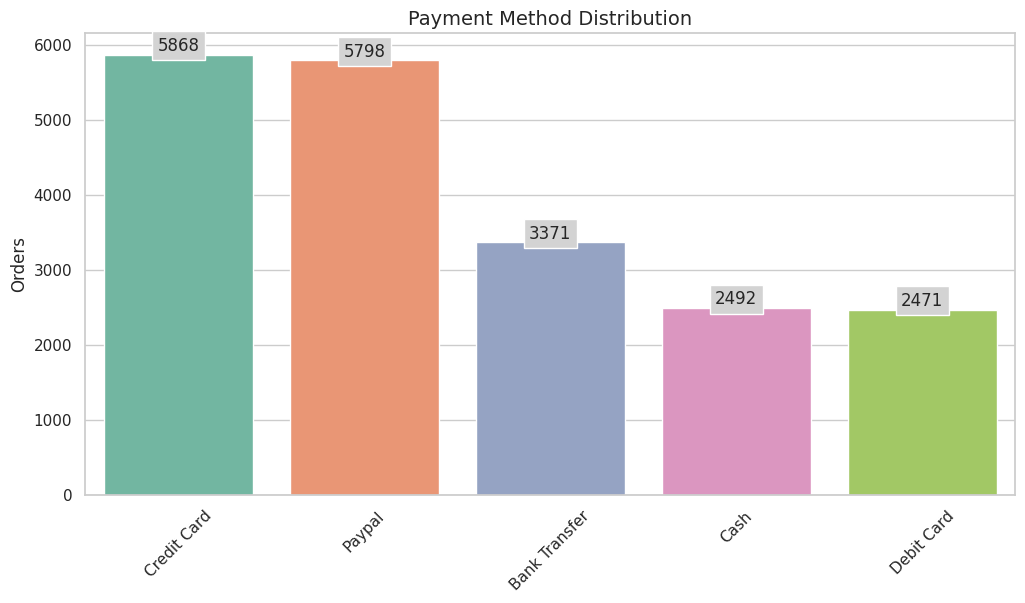

In [88]:
# Calculate count of each payment method
payment_counts = df_eda['Payment Method'].value_counts()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_eda,x='Payment Method',order=payment_counts.index,palette='Set2')

# Customize the plot
plt.title('Payment Method Distribution', fontsize=14)
plt.xlabel('')
plt.ylabel('Orders')

# Show the plot
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, bbox=dict(facecolor='lightgrey'))

plt.show()

In [89]:
Avg_order_by_payment = df_eda.groupby('Payment Method')['Total Price'].mean().round(2).reset_index()
Avg_order_by_payment.sort_values(by='Total Price', ascending=False)

,Payment Method,Total Price
0,Bank Transfer,3766.91
4,Paypal,3276.79
2,Credit Card,3223.21
3,Debit Card,2726.11
1,Cash,2510.26


In [90]:
payment_type_completion = completed_orders.groupby('Payment Method')['Order Status'].value_counts().reset_index(name='Count')
payment_type_completion['Percent Completed'] = ((payment_type_completion['Count'] / 20000) * 100).round(2)
payment_type_completion = payment_type_completion.sort_values(by='Count', ascending=False)
payment_type_completion

,Payment Method,Order Status,Count,Percent Completed
2,Credit Card,Completed,3899,19.50
0,Bank Transfer,Completed,2259,11.30
4,PayPal,Completed,2235,11.18
1,Cash,Completed,1727,8.64
3,Debit Card,Completed,1684,8.42
5,Paypal,Completed,1628,8.14


In [91]:
payment_counts = loyalty_df.groupby(['Loyalty Status', 'Payment Method']).size().reset_index(name='Count')
payment_counts.sort_values(by=['Count'], ascending=False).head()

,Loyalty Status,Payment Method,Count
14,Non Member,Credit Card,4227
12,Non Member,Bank Transfer,2386
16,Non Member,PayPal,2323
13,Non Member,Cash,1804
17,Non Member,Paypal,1776


In [92]:
# top payment method for each loyalty status
top_payment_methods = payment_counts.loc[payment_counts.groupby('Loyalty Status')['Count'].idxmax()]

top_payment_methods.sort_values(by='Count', ascending=False)

,Loyalty Status,Payment Method,Count
14,Non Member,Credit Card,4227
20,Regular Member,Credit Card,833
2,Churned,Credit Card,413
8,New Member,Credit Card,395


# **Data Transformation**

##### Preparing DataFrame for Preprocessing

In [93]:
df_prep = df_eda.copy()
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        20000 non-null  int64         
 1   Age                20000 non-null  int64         
 2   Gender             20000 non-null  object        
 3   Loyalty Member     20000 non-null  object        
 4   Product Type       20000 non-null  object        
 5   Rating             20000 non-null  int64         
 6   Order Status       20000 non-null  object        
 7   Payment Method     20000 non-null  object        
 8   Total Price        20000 non-null  float64       
 9   Unit Price         20000 non-null  float64       
 10  Quantity           20000 non-null  int64         
 11  Purchase Date      20000 non-null  datetime64[ns]
 12  Shipping Type      20000 non-null  object        
 13  Add-ons Purchased  20000 non-null  object        
 14  Add-on

In [94]:
df_prep.drop(columns=['Customer ID'],inplace=True)

In [95]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Age                20000 non-null  int64         
 1   Gender             20000 non-null  object        
 2   Loyalty Member     20000 non-null  object        
 3   Product Type       20000 non-null  object        
 4   Rating             20000 non-null  int64         
 5   Order Status       20000 non-null  object        
 6   Payment Method     20000 non-null  object        
 7   Total Price        20000 non-null  float64       
 8   Unit Price         20000 non-null  float64       
 9   Quantity           20000 non-null  int64         
 10  Purchase Date      20000 non-null  datetime64[ns]
 11  Shipping Type      20000 non-null  object        
 12  Add-ons Purchased  20000 non-null  object        
 13  Add-on Total       20000 non-null  float64       
 14  YearMo

In [96]:
numerical_cols = df_prep.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

categorical_cols = df_prep.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Age', 'Rating', 'Total Price', 'Unit Price', 'Quantity', 'Add-on Total']

Categorical Columns:
['Gender', 'Loyalty Member', 'Product Type', 'Order Status', 'Payment Method', 'Shipping Type', 'Add-ons Purchased']


##### Handle Duplicates

In [97]:
df_prep.duplicated().sum()

np.int64(0)

##### Handling Inconsistencies

In [98]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df_prep[col].unique())
    print(f"Total Unique Values: {df_prep[col].nunique()}")


Column: Gender
['Male' 'Female']
Total Unique Values: 2

Column: Loyalty Member
['No' 'Yes']
Total Unique Values: 2

Column: Product Type
['Smartphone' 'Tablet' 'Laptop' 'Smartwatch' 'Headphones']
Total Unique Values: 5

Column: Order Status
['Cancelled' 'Completed']
Total Unique Values: 2

Column: Payment Method
['Credit Card' 'Paypal' 'Cash' 'Debit Card' 'Bank Transfer']
Total Unique Values: 5

Column: Shipping Type
['Standard' 'Overnight' 'Express' 'Same Day' 'Expedited']
Total Unique Values: 5

Column: Add-ons Purchased
['Accessory,Accessory,Accessory' 'Impulse Item' 'None'
 'Impulse Item,Impulse Item' 'Accessory' 'Impulse Item,Accessory'
 'Extended Warranty,Extended Warranty'
 'Impulse Item,Accessory,Impulse Item' 'Accessory,Extended Warranty'
 'Extended Warranty,Impulse Item,Extended Warranty'
 'Accessory,Impulse Item,Accessory' 'Impulse Item,Extended Warranty'
 'Impulse Item,Accessory,Extended Warranty'
 'Extended Warranty,Impulse Item' 'Accessory,Accessory'
 'Extended Warranty

##### Handle Outliers

In [99]:
numerical_cols = [
    'Age',
    'Rating',
    'Total Price',
    'Unit Price',
    'Quantity',
    'Add-on Total'
]

exclude_cols = ['Rating']

outlier_cols = [
    col for col in numerical_cols
    if col not in exclude_cols
]

print(f"Data shape before removing outliers: {df_prep.shape}")

for col in outlier_cols:

    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df_prep = df_prep[
        (df_prep[col] >= lower_bound) &
        (df_prep[col] <= upper_bound)
    ]

df_prep = df_prep.reset_index(drop=True)

print(f"Data shape after removing outliers: {df_prep.shape}")

Data shape before removing outliers: (20000, 15)
Data shape after removing outliers: (19373, 15)


#### Encoding

In [100]:
df_prep['Gender'] = df_prep['Gender'].map({
    'Male': 1,
    'Female': 0
})

df_prep['Loyalty Member'] = df_prep['Loyalty Member'].map({
    'Yes': 1,
    'No': 0
})

df_prep['Order Status'] = df_prep['Order Status'].map({
    'Completed': 1,
    'Cancelled': 0
})

df_prep['Add-ons Purchased'] = (
    df_prep['Add-ons Purchased']
    .fillna('None')
    .str.replace(', ', ',', regex=False)
    .apply(
        lambda x: ','.join(sorted(x.split(',')))
        if x != 'None' else x
    )
)

df_prep = pd.get_dummies(
    df_prep,
    columns=[
        'Product Type',
        'Payment Method',
        'Shipping Type',
        'Add-ons Purchased'
    ],
    drop_first=True
)

df_prep['Purchase Date'] = pd.to_datetime(
    df_prep['Purchase Date']
)

df_prep['Year'] = df_prep['Purchase Date'].dt.year
df_prep['Month'] = df_prep['Purchase Date'].dt.month
df_prep['Day_of_Week'] = df_prep['Purchase Date'].dt.dayofweek

df_prep.drop(columns=['Purchase Date'], inplace=True)

bool_cols = df_prep.select_dtypes(include='bool').columns

df_prep[bool_cols] = df_prep[bool_cols].astype(int)

#### Scaling

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    'Age',
    'Rating',
    'Total Price',
    'Unit Price',
    'Quantity',
    'Add-on Total'
]

df_prep[scale_cols] = scaler.fit_transform(
    df_prep[scale_cols]
)

#### Feature Selection (Mutual Information)

###### Classification Problem

In [102]:
from sklearn.feature_selection import mutual_info_classif

X_class = df_prep.drop(columns=[
    'Order Status',
    'YearMonth'
])

y_class = df_prep['Order Status']

discrete_features = X_class.dtypes == int

mi_class_scores = mutual_info_classif(
    X_class,
    y_class,
    discrete_features=discrete_features,
    random_state=42
)

mi_class_df = pd.DataFrame({
    'Feature': X_class.columns,
    'MI Score': mi_class_scores
})

mi_class_df = mi_class_df.sort_values(
    by='MI Score',
    ascending=False
)

print(mi_class_df)

                                              Feature      MI Score
41                                        Day_of_Week  3.737661e-03
5                                          Unit Price  2.797186e-03
3                                              Rating  2.700640e-03
7                                        Add-on Total  2.415956e-03
0                                                 Age  2.252585e-03
40                                              Month  9.920169e-04
12                                Payment Method_Cash  1.594323e-04
1                                              Gender  5.398554e-05
13                         Payment Method_Credit Card  5.351196e-05
16                              Shipping Type_Express  4.446595e-05
31  Add-ons Purchased_Extended Warranty,Extended W...  4.015660e-05
14                          Payment Method_Debit Card  3.469514e-05
15                              Payment Method_Paypal  3.044112e-05
34  Add-ons Purchased_Extended Warranty,Impulse 

###### Select Features

In [104]:
# Classif
selected_class_features = mi_class_df[
    mi_class_df['MI Score'] > 0.001
]['Feature'].tolist()

X_class_selected = X_class[selected_class_features]

print(selected_class_features)
print(f"Total Selected Features: {len(selected_class_features)}")

['Day_of_Week', 'Unit Price', 'Rating', 'Add-on Total', 'Age']
Total Selected Features: 5


## **Modeling**

##### Model Fitting

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

###### Classification Problem

In [115]:
# Random Forest
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_selected,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

clf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

clf_model.fit(X_train_c, y_train_c)

y_pred_c = clf_model.predict(X_test_c)

In [120]:
# XGBoost
X = df_prep.drop(['Order Status', 'YearMonth'], axis=1)
y = df_prep['Order Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

##### Model Evaluation (Classification Problem)


###### Confusion Matrix

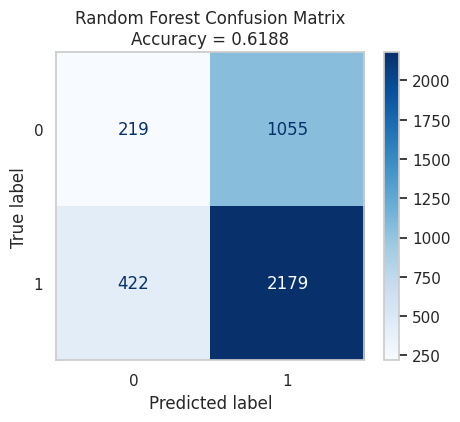

In [130]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

accuracy = accuracy_score(y_test_c, y_pred_c)
cm = confusion_matrix(y_test_c, y_pred_c)
fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues')

ax.grid(False)
plt.title(f'Random Forest Confusion Matrix\nAccuracy = {accuracy:.4f}')
plt.show()

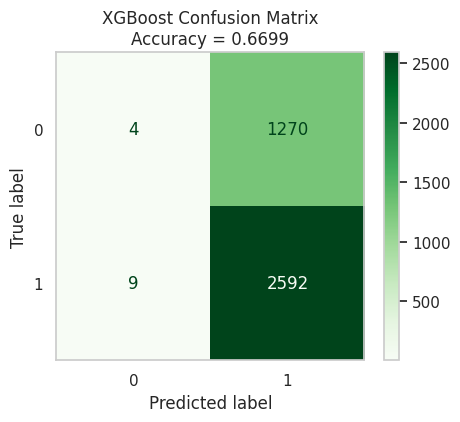

In [132]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Greens')

ax.grid(False)
plt.title(f'XGBoost Confusion Matrix\nAccuracy = {accuracy:.4f}')
plt.show()

###### Classification Report

In [126]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score

print("Classification Report Random Forest")
print(classification_report(y_test_c, y_pred_c))

# F1 Score
f1 = f1_score(y_test_c, y_pred_c)

# ROC AUC
y_prob_c = clf_model.predict_proba(X_test_c)[:, 1]
roc_auc = roc_auc_score(y_test_c, y_prob_c)

print(f"ROC AUC  : {roc_auc:.4f}")

Classification Report Random Forest
              precision    recall  f1-score   support

           0       0.34      0.17      0.23      1274
           1       0.67      0.84      0.75      2601

    accuracy                           0.62      3875
   macro avg       0.51      0.50      0.49      3875
weighted avg       0.56      0.62      0.58      3875

ROC AUC  : 0.5107


In [127]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score

print('Classification Report XGBoost')
print(classification_report(y_test, y_pred))

# ROC AUC
y_prob = xgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print(f'ROC AUC  : {roc_auc:.4f}')

Classification Report XGBoost
              precision    recall  f1-score   support

           0       0.31      0.00      0.01      1274
           1       0.67      1.00      0.80      2601

    accuracy                           0.67      3875
   macro avg       0.49      0.50      0.40      3875
weighted avg       0.55      0.67      0.54      3875

ROC AUC  : 0.5019
